### Initial Data Checks and Visualization Setup

In [1]:
from pathlib import Path


DATA_DIR = Path("../benchmarks/layer/data")
assert DATA_DIR.exists(), f"Data directory not found: {DATA_DIR.resolve()}"

In [2]:
import sys
from pathlib import Path


project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [3]:
import torch
import random
import numpy as np


random.seed(0)
torch.manual_seed(0)
np.random.seed(0)

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Theme
sns.set_theme(style="whitegrid", rc={"font.family": "serif"})
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 300

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Palette
PALETTE = ["#9ecae1", "#6baed6", "#3182bd", "#08519c", "#023a73", "#001c38"]
MARKERS = ["o", "s", "p", "h"]

### Analyzing Suitability of Simple Low-Rank Approximation for Quantization

In [5]:
from collections import defaultdict


def save_figure(fig: plt.Figure, name: str):
    """Saves visualization figure in PDF format."""
    fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight", format="pdf")

def load_layers(data_dir: Path) -> dict:
    """Scans the dataset directory and groups files by layer type."""
    layer_groups = defaultdict(list)
    for file_path in data_dir.glob("*.pt"):
        parts = file_path.stem.split("__")
        if len(parts) != 3:
            continue
        _, layer_full_name, _ = parts
        layer_type = layer_full_name.split(".")[-1]
        layer_groups[layer_type].append(file_path)
    return layer_groups

def get_qmax(bits: int) -> float:
    """Calculates the maximum representable value for symmetric signed integers."""
    return (2 ** (bits - 1)) - 1.0

def aggregate_matrix(matrix: np.ndarray, target_shape: tuple, methods: tuple) -> np.ndarray:
    """Aggregates an N-dimensional array to a specific target shape using axis-specific methods."""
    result = matrix
    for axis in range(matrix.ndim):
        num_bins = target_shape[axis]
        method = methods[axis]

        # Skip aggregation if dimension already matches target
        if num_bins == result.shape[axis] or num_bins <= 0:
            continue

        splits = np.array_split(result, num_bins, axis=axis)
        aggregated = []

        for split in splits:
            if split.shape[axis] == 0:
                    continue

            if method == 'max':
                aggregated.append(np.max(split, axis=axis))
            elif method == 'mean':
                aggregated.append(np.mean(split, axis=axis))
            elif method == 'max_abs':
                max_idx = np.argmax(np.abs(split), axis=axis, keepdims=True)
                max_vals = np.take_along_axis(split, max_idx, axis=axis).squeeze(axis=axis)
                aggregated.append(max_vals)
            else:
                raise ValueError(f"Unsupported aggregation method: {method}")

        result = np.stack(aggregated, axis=axis)

    return result

def shade_bounds(ax, x, upper_y, lower_y, upper_color, lower_color):
    """Shades regions upper and lower than certain values."""
    y_min, y_max = ax.get_ylim()

    ax.fill_between(
        x, upper_y, y_max,
        facecolor=upper_color,
        alpha=0.08,
        hatch="///",
        edgecolor=upper_color,
        linewidth=1.0,
        zorder=0,
    )
    ax.fill_between(
        x, y_min, lower_y,
        facecolor=lower_color,
        alpha=0.08,
        hatch="///",
        edgecolor=lower_color,
        linewidth=1.0,
        zorder=0,
    )
    ax.set_ylim(y_min, y_max)

# Load global dataset references
layer_groups = load_layers(DATA_DIR)
print(f"Found layer types: {list(layer_groups.keys())}")

Found layer types: ['k_proj', 'o_proj', 'q_proj', 'down_proj', 'gate_proj']


In [6]:
# Configuration
BIT_WIDTHS = [2, 4, 8]
GROUP_SIZES = [1, 2, 4, 8, 16, 32, 64, 128, 256]
TARGET_LAYER = "o_proj"
SAMPLE_SIZE = 3

In [7]:
import pandas as pd

from lrsr.decomposition.upperbounding_decomposition import UpperboundingDecomposition
from lrsr.approximation.rank_approximation import RankApproximation
from lrsr.metrics import mse


layer_files = layer_groups[TARGET_LAYER]
sampled_files = random.sample(layer_files, min(SAMPLE_SIZE, len(layer_files)))
all_results = []

rank_approximator = RankApproximation(UpperboundingDecomposition())

for file_path in sampled_files:
    data = torch.load(file_path, weights_only=False)
    W = data['W'].to(torch.float32)
    in_features, out_features = W.shape
    W_var = torch.var(W).item()

    for bits in BIT_WIDTHS:
        qmax = get_qmax(bits)

        for g in GROUP_SIZES:
            if in_features % g != 0:
                continue

            # Build ideal scales
            W_reshaped = W.view(in_features // g, g, out_features)
            S_pg_ideal = torch.clamp(W_reshaped.abs().max(dim=1)[0] / qmax, min=1e-7)

            # Approximateusing low-rank
            S_approx = torch.clamp(rank_approximator.approximate(S_pg_ideal, rank=1), min=1e-7)

            # Expand and dequantize
            S_exp = S_approx.repeat_interleave(g, dim=0)
            W_deq = torch.clamp(torch.round(W / S_exp), -qmax, qmax) * S_exp

            # Record the error
            mse_val = mse(W, W_deq) / W_var

            all_results.append({
                "Bits": bits,
                "Group Size": g,
                "MSE_Rank1": mse_val
            })

df_group_analysis = pd.DataFrame(all_results).groupby(['Bits', 'Group Size'], as_index=False).median()

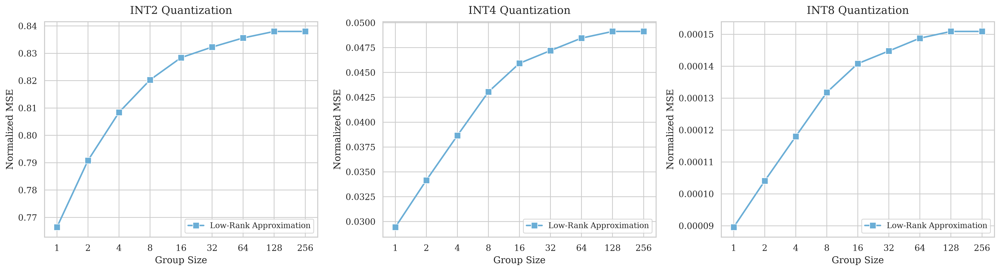

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for idx, bits in enumerate(BIT_WIDTHS):
    ax = axes[idx]
    df_plot = df_group_analysis[df_group_analysis["Bits"] == bits].sort_values("Group Size")

    sns.lineplot(
        data=df_plot, x="Group Size", y="MSE_Rank1", marker=MARKERS[1], color=PALETTE[1],
        linewidth=2.0, markersize=8, label="Low-Rank Approximation", ax=ax
    )

    ax.set_title(f"INT{bits} Quantization", fontsize=14, pad=10)
    ax.set_xlabel("Group Size", fontsize=12)
    ax.set_ylabel("Normalized MSE", fontsize=12)

    ax.set_xscale("log", base=2)
    ax.set_xticks(GROUP_SIZES)
    ax.set_xticklabels(GROUP_SIZES)

    ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
save_figure(fig, "1a_group_size_analysis")
plt.show()

In [9]:
# Configuration
TARGET_LAYER = "o_proj"
BIT_WIDTH = 4
GROUP_SIZE = 128

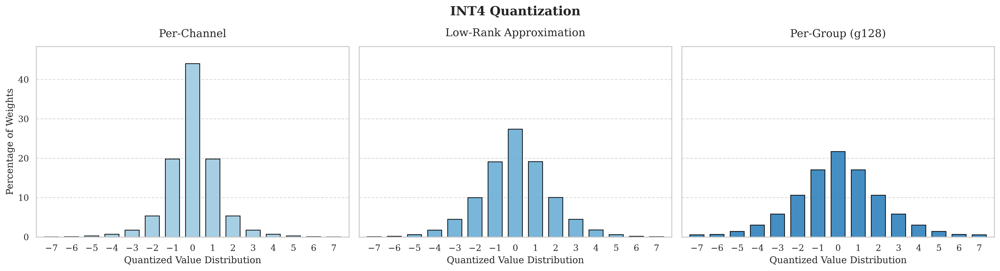

In [10]:
# Load a single representative layer
file_path = layer_groups[TARGET_LAYER][0]
data = torch.load(file_path, weights_only=False)
W = data['W'].to(torch.float32)
in_features, out_features = W.shape

qmax = get_qmax(BIT_WIDTH)
qmax_int = int(qmax)

# Compute Quantized Weights for three strategies
S_ideal_element = torch.clamp(W.abs() / qmax, min=1e-7)

# Per-Channel
S_pc = S_ideal_element.max(dim=0, keepdim=True)[0].expand_as(S_ideal_element)
W_q_pc = torch.clamp(torch.round(W / S_pc), -qmax, qmax)

# Low-Rank Approximation
S_lra = torch.clamp(rank_approximator.approximate(S_ideal_element, rank=1), min=1e-7)
W_q_lra = torch.clamp(torch.round(W / S_lra), -qmax, qmax)

# Per-Group
W_reshaped = W.view(in_features // GROUP_SIZE, GROUP_SIZE, out_features)
S_pg = torch.clamp(W_reshaped.abs().max(dim=1)[0] / qmax, min=1e-7)
S_pg_exp = S_pg.repeat_interleave(GROUP_SIZE, dim=0)
W_q_pg = torch.clamp(torch.round(W / S_pg_exp), -qmax, qmax)

# Fuction for Calculating Probability Mass Functions
def get_pmf(w_q_tensor: torch.Tensor, limit: int) -> tuple:
    """Calculates the probability mass function of quantized integer values."""
    bins = np.arange(-limit, limit + 1)
    counts = np.bincount((w_q_tensor + limit).cpu().numpy().flatten().astype(int), minlength=len(bins))
    pmf = (counts / counts.sum()) * 100.0
    return bins, pmf

bins, dist_pc = get_pmf(W_q_pc, qmax_int)
_, dist_lra = get_pmf(W_q_lra, qmax_int)
_, dist_pg = get_pmf(W_q_pg, qmax_int)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

titles = [
    "Per-Channel",
    "Low-Rank Approximation",
    f"Per-Group (g{GROUP_SIZE})"
]
distributions = [dist_pc, dist_lra, dist_pg]

for i, (ax, dist, title, color) in enumerate(zip(axes, distributions, titles, PALETTE)):
    ax.bar(bins, dist, width=0.7, color=color, edgecolor="black", linewidth=1.0, alpha=0.9)

    if i == len(titles) // 2:
        ax.set_title("INT4 Quantization", fontsize=16, fontweight="bold", pad=40)
        ax.text(0.5, 1.04, title, transform=ax.transAxes, ha="center", va="bottom", fontsize=14)
    else:
        ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel(f"Quantized Value Distribution", fontsize=12)

    ax.set_xticks(bins)
    ax.set_xlim(-qmax_int - 0.75, qmax_int + 0.75)

    ax.grid(axis='x')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

axes[0].set_ylabel("Percentage of Weights", fontsize=12)
max_peak = max(dist_pc.max(), dist_lra.max(), dist_pg.max())
axes[0].set_ylim(0, max_peak * 1.1)

plt.tight_layout()
save_figure(fig, "1b_dynamic_range_utilization")
plt.show()

In [11]:
# Configuration
BIT_WIDTHS = [2, 4, 8]
GROUP_SIZES = [8, 16, 32, 64, 128, 256]
TARGET_LAYER = "o_proj"
SAMPLE_SIZE = 3

In [12]:
layer_files = layer_groups[TARGET_LAYER]
sampled_files = random.sample(layer_files, min(SAMPLE_SIZE, len(layer_files)))
all_results = []

for file_path in sampled_files:
    data = torch.load(file_path, weights_only=False)
    W = data['W'].to(torch.float32)
    in_features, out_features = W.shape
    W_var = torch.var(W).item()

    for bits in BIT_WIDTHS:
        qmax = get_qmax(bits)

        # Per-Channel
        S_pc = torch.clamp(W.abs().max(dim=0, keepdim=True)[0] / qmax, min=1e-7)
        W_deq_pc = torch.clamp(torch.round(W / S_pc), -qmax, qmax) * S_pc
        mse_pc = mse(W, W_deq_pc) / W_var

        # Low-Rank Approximation
        S_ideal_element = torch.clamp(W.abs() / qmax, min=1e-7)
        S_lra = torch.clamp(rank_approximator.approximate(S_ideal_element, rank=1), min=1e-7)
        W_deq_lra = torch.clamp(torch.round(W / S_lra), -qmax, qmax) * S_lra
        mse_lra = mse(W, W_deq_lra) / W_var

        for g in GROUP_SIZES:
            if in_features % g != 0:
                continue

            # Per-Group
            W_reshaped = W.view(in_features // g, g, out_features)
            S_pg = torch.clamp(W_reshaped.abs().max(dim=1)[0] / qmax, min=1e-7)
            S_pg_exp = S_pg.repeat_interleave(g, dim=0)

            W_deq_pg = torch.clamp(torch.round(W / S_pg_exp), -qmax, qmax) * S_pg_exp
            mse_pg = mse(W, W_deq_pg) / W_var

            # Calculate gap closed
            gap_total = mse_pc - mse_pg
            gap_closed = (mse_pc - mse_lra) / gap_total if gap_total > 0 else 0.0

            all_results.append({
                "Bits": bits,
                "Group Size": g,
                "MSE_PC": mse_pc,
                "MSE_PG": mse_pg,
                "MSE_LRA": mse_lra,
                "Gap_Closed": gap_closed * 100.0
            })

# Aggregate sampled runs using median
df = pd.DataFrame(all_results).groupby(['Bits', 'Group Size'], as_index=False).median()

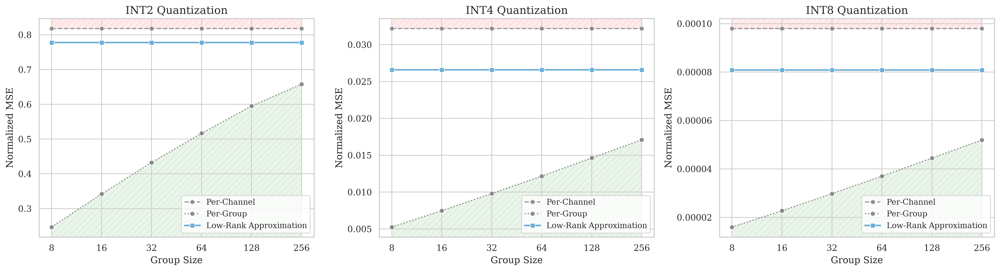

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for idx, bits in enumerate(BIT_WIDTHS):
    ax = axes[idx]
    df_plot = df[(df["Bits"] == bits)]

    # Baselines
    sns.lineplot(data=df_plot, x="Group Size", y="MSE_PC", marker="o", color="gray", linestyle="--", alpha=0.8, label="Per-Channel", ax=ax)
    sns.lineplot(data=df_plot, x="Group Size", y="MSE_PG", marker="o", color="gray", linestyle=":", alpha=0.9, label="Per-Group", ax=ax)

    # Low-Rank Approximation
    if f"MSE_LRA" in df_plot.columns:
        sns.lineplot(
            data=df_plot,
            x="Group Size",
            y=f"MSE_LRA",
            marker=MARKERS[1],
            color=PALETTE[1],
            linewidth=2.0,
            label=f"Low-Rank Approximation",
            ax=ax
        )

    ax.set_title(f"INT{bits} Quantization", fontsize=14)
    ax.set_xlabel("Group Size", fontsize=12)
    ax.set_ylabel("Normalized MSE", fontsize=12)
    ax.set_xscale("log", base=2)
    ax.set_xticks(GROUP_SIZES)
    ax.set_xticklabels(GROUP_SIZES)

    df_plot = df_plot.sort_values("Group Size")

    ax.set_xscale("log", base=2)
    ax.set_xticks(GROUP_SIZES)
    ax.set_xticklabels(GROUP_SIZES)

    shade_bounds(
        ax,
        df_plot["Group Size"],
        df_plot["MSE_PC"],
        df_plot["MSE_PG"],
        "red",
        "green",
    )

    ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
save_figure(fig, "1c_weight_error_comparison")
plt.show()

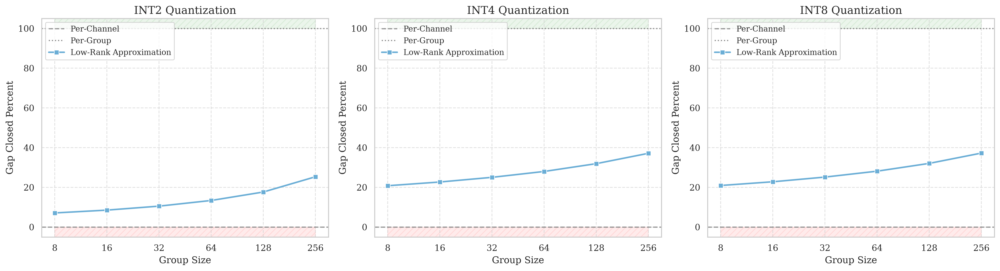

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for idx, bits in enumerate(BIT_WIDTHS):
    ax = axes[idx]
    df_plot = df[(df["Bits"] == bits)]

    # Baselines
    ax.axhline(0, color='gray', linestyle='--', label="Per-Channel", alpha=0.8)
    ax.axhline(100, color='gray', linestyle=':', label="Per-Group", alpha=0.9)

    # Low-Rank Approximation
    if f"Gap_Closed" in df_plot.columns:
        sns.lineplot(
            data=df_plot,
            x="Group Size",
            y=f"Gap_Closed",
            marker=MARKERS[1],
            color=PALETTE[1],
            linewidth=2.0,
            label=f"Low-Rank Approximation",
            ax=ax
        )

    ax.set_title(f"INT{bits} Quantization", fontsize=14)
    ax.set_xlabel("Group Size", fontsize=12)
    ax.set_ylabel("Gap Closed Percent", fontsize=12)
    ax.set_xscale("log", base=2)
    ax.set_xticks(GROUP_SIZES)
    ax.set_xticklabels(GROUP_SIZES)
    ax.grid(True, which="both", ls="--", alpha=0.6)

    df_plot = df_plot.sort_values("Group Size")

    ax.set_xscale("log", base=2)
    ax.set_xticks(GROUP_SIZES)
    ax.set_xticklabels(GROUP_SIZES)
    ax.grid(True, which="both", ls="--", alpha=0.6)

    shade_bounds(
        ax,
        df_plot["Group Size"],
        100.0,
        0.0,
        "green",
        "red",
    )

    ax.legend(loc="upper left", fontsize=10)

plt.tight_layout()
save_figure(fig, "1d_weight_error_gap_closed")
plt.show()

### Visualizing Low-Rank Scale Reconstuction Quality

In [15]:
# Configuration
TARGET_LAYER = "o_proj"
BIT_WIDTH = 4
VIS_BINS = (128, 128)

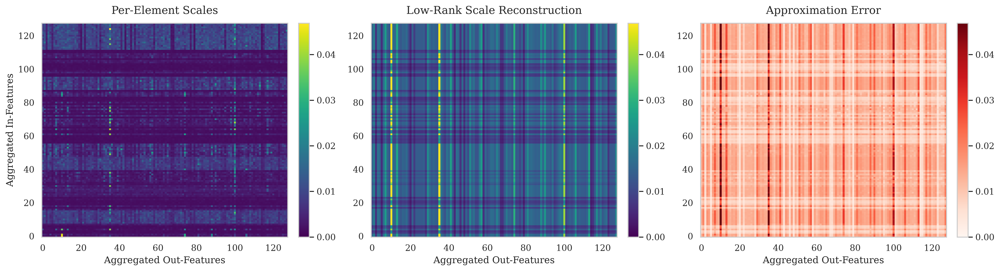

In [16]:
# Load a single representative layer
file_path = layer_groups[TARGET_LAYER][0]
data = torch.load(file_path, weights_only=False)
W = data['W'].to(torch.float32)
qmax = get_qmax(BIT_WIDTH)

# Compute Per-Element Scales
S_ideal = torch.clamp(W.abs() / qmax, min=1e-7)

# Compute Low-Rank Scale Reconstruction
S_lrsr = torch.clamp(rank_approximator.approximate(S_ideal, rank=1), min=1e-7)

# Compute Scale Approximation Error
S_error = S_lrsr - S_ideal

# Aggregate matrices for visualization
agg_S_ideal = aggregate_matrix(S_ideal.cpu().numpy(), VIS_BINS, ('max', 'max'))
agg_S_lrsr  = aggregate_matrix(S_lrsr.cpu().numpy(), VIS_BINS, ('max', 'max'))
agg_S_error = aggregate_matrix(S_error.cpu().numpy(), VIS_BINS, ('max', 'max'))

# Determine global colorbar limits
vmax_scale = max(agg_S_ideal.max(), agg_S_lrsr.max())
vmax_err = np.max(np.abs(agg_S_error))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Per-Element Scales
im0 = axes[0].imshow(agg_S_ideal, cmap="viridis", aspect="auto", origin="lower", vmin=0, vmax=vmax_scale)
axes[0].set_title("Per-Element Scales", fontsize=14, pad=12)
axes[0].set_ylabel("Aggregated In-Features", fontsize=12)
axes[0].set_xlabel("Aggregated Out-Features", fontsize=12)
axes[0].grid(False)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Low-Rank Scale Reconstruction
im1 = axes[1].imshow(agg_S_lrsr, cmap="viridis", aspect="auto", origin="lower", vmin=0, vmax=vmax_scale)
axes[1].set_title("Low-Rank Scale Reconstruction", fontsize=14, pad=12)
axes[1].set_xlabel("Aggregated Out-Features", fontsize=12)
axes[1].grid(False)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Approximation Error
im2 = axes[2].imshow(agg_S_error, cmap="Reds", aspect="auto", origin="lower", vmin=0, vmax=vmax_err)
axes[2].set_title("Approximation Error", fontsize=14, pad=12)
axes[2].set_xlabel("Aggregated Out-Features", fontsize=12)
axes[2].grid(False)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
save_figure(fig, "2a_scale_approximation_error")
plt.show()

In [17]:
from typing import List


def plot_error_analysis(
    col_titles: List[str],
    row_data: List[List[np.ndarray]],
    row_ylabels: List[str],
    row_titles: List[str] = ["Tensor Scales", "Dequantization Error", "MatMul Error"],
    row_cmaps: List[str] = ["viridis", "Reds", "inferno"],
    save_name: str = None
):
    """Renders a 3x3 grid comparing Scales, Weight Errors, and MatMul Errors across 3 methods."""
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))

    for row_idx in range(3):
        row_max = max([arr.max() for arr in row_data[row_idx]])
        cmap = row_cmaps[row_idx]

        for col_idx in range(3):
            ax = axes[row_idx, col_idx]
            data = row_data[row_idx][col_idx]

            im = ax.imshow(data, cmap=cmap, aspect="auto", origin="lower", vmin=0, vmax=row_max)
            ax.grid(False)

            if row_idx == 0:
                ax.set_title(col_titles[col_idx], fontsize=16, fontweight="bold", color="black", pad=30)
                ax.text(0.5, 1.02, row_titles[row_idx], transform=ax.transAxes, ha="center", va="bottom", fontsize=14)
            else:
                ax.set_title(row_titles[row_idx], fontsize=14)

            if col_idx == 0:
                ax.set_ylabel(row_ylabels[row_idx], fontsize=12)

            if row_idx == 2:
                ax.set_xlabel("Aggregated Out-Features", fontsize=12)

            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()

def compute_weight_error(w_orig: torch.Tensor, scales: torch.Tensor, q_limit: float) -> torch.Tensor:
    """Quantizes, dequantizes, and computes absolute error."""
    w_dq = torch.clamp(torch.round(w_orig / scales), -q_limit, q_limit) * scales
    return torch.abs(w_orig - w_dq), w_dq

def agg(tensor, bins):
    """Aggregation helper."""
    return aggregate_matrix(tensor.cpu().numpy(), bins, ('max', 'max'))

In [18]:
# Configuration
TARGET_LAYER = "o_proj"
BIT_WIDTH = 4
GROUP_SIZE = 128
VIS_BINS = (128, 128)

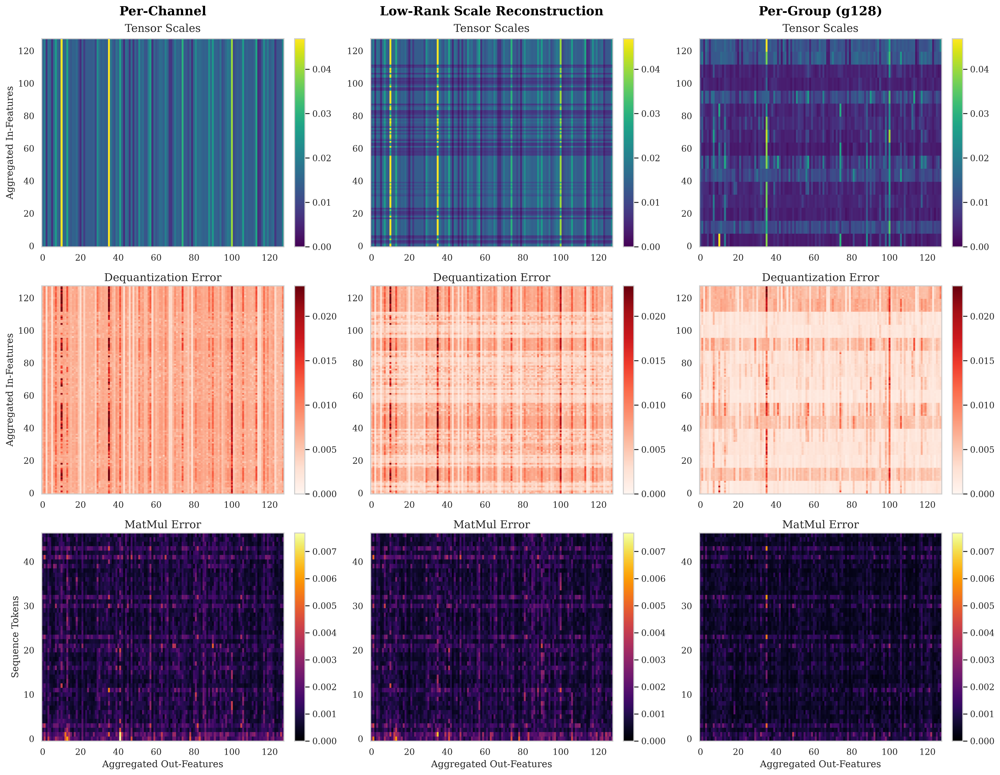

In [19]:
# Load weights and activations
file_path = layer_groups[TARGET_LAYER][0]
data = torch.load(file_path, weights_only=False)
W = data['W'].to(torch.float32)
A = data['A'].to(torch.float32)

if len(A.shape) == 3:
    A = A.view(-1, A.shape[-1])

qmax = get_qmax(BIT_WIDTH)
in_features, out_features = W.shape

# Compute Scales
S_ideal = torch.clamp(W.abs() / qmax, min=1e-7)

# Per-Channel
S_pc = S_ideal.max(dim=0, keepdim=True)[0].expand_as(S_ideal)

# Low-Rank Scale Reconstruction
S_lrsr = torch.clamp(rank_approximator.approximate(S_ideal, rank=1), min=1e-7)

# Per-Group
W_reshaped = W.view(in_features // GROUP_SIZE, GROUP_SIZE, out_features)
S_pg = torch.clamp(W_reshaped.abs().max(dim=1)[0] / qmax, min=1e-7)
S_pg = S_pg.repeat_interleave(GROUP_SIZE, dim=0)

# Compute Dequantized Weights and Absolute Error
Err_W_pc, W_dq_pc = compute_weight_error(W, S_pc, qmax)
Err_W_lrsr, W_dq_lrsr = compute_weight_error(W, S_lrsr, qmax)
Err_W_pg, W_dq_pg = compute_weight_error(W, S_pg, qmax)

# Compute MatMul Absolute Error
with torch.no_grad():
    Y_true = torch.matmul(A, W)
    Err_Y_pc = torch.abs(Y_true - torch.matmul(A, W_dq_pc))
    Err_Y_lrsr = torch.abs(Y_true - torch.matmul(A, W_dq_lrsr))
    Err_Y_pg = torch.abs(Y_true - torch.matmul(A, W_dq_pg))

# Aggregate matrices
scales_row = [agg(S_pc, VIS_BINS), agg(S_lrsr, VIS_BINS), agg(S_pg, VIS_BINS)]
weights_row = [agg(Err_W_pc, VIS_BINS), agg(Err_W_lrsr, VIS_BINS), agg(Err_W_pg, VIS_BINS)]
matmul_row = [agg(Err_Y_pc, VIS_BINS), agg(Err_Y_lrsr, VIS_BINS), agg(Err_Y_pg, VIS_BINS)]

# Visualization
col_titles = [
    "Per-Channel",
    "Low-Rank Scale Reconstruction",
    f"Per-Group (g{GROUP_SIZE})"
]
row_ylabels = [
    "Aggregated In-Features",
    "Aggregated In-Features",
    "Sequence Tokens"
]

plot_error_analysis(
    col_titles=col_titles,
    row_data=[scales_row, weights_row, matmul_row],
    row_ylabels=row_ylabels,
    save_name="2b_common_quants_error_analysis"
)

In [20]:
# Configuration
PATCH_H, PATCH_W = 32, 32
R_START = GROUP_SIZE - PATCH_H // 2
C_START = 256

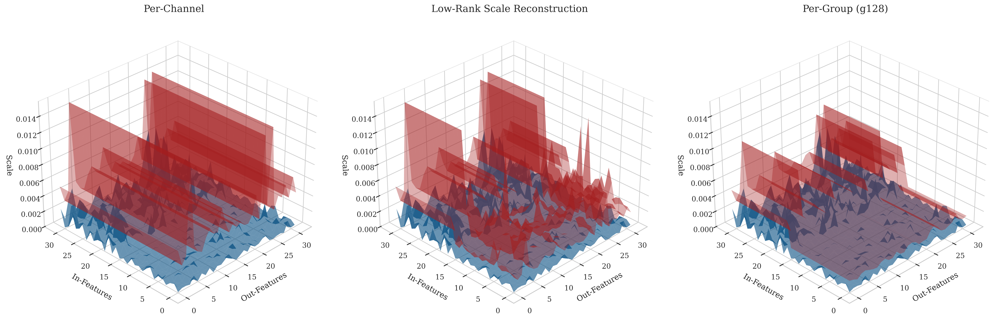

In [21]:
# Extract raw slices
Z_ideal = S_ideal[R_START:R_START+PATCH_H, C_START:C_START+PATCH_W].cpu().numpy()
Z_pc    = S_pc[R_START:R_START+PATCH_H, C_START:C_START+PATCH_W].cpu().numpy()
Z_lrsr  = S_lrsr[R_START:R_START+PATCH_H, C_START:C_START+PATCH_W].cpu().numpy()
Z_pg    = S_pg[R_START:R_START+PATCH_H, C_START:C_START+PATCH_W].cpu().numpy()

# Create spatial grid
x = np.arange(PATCH_W)
y = np.arange(PATCH_H)
X, Y = np.meshgrid(x, y)
z_min = 0.0
z_max = max(Z_pc.max(), Z_lrsr.max(), Z_pg.max()) * 1.05

# Visualization
fig = plt.figure(figsize=(22, 7))

titles = [
    "Per-Channel",
    "Low-Rank Scale Reconstruction",
    f"Per-Group (g{GROUP_SIZE})"
]
approx_patches = [Z_pc, Z_lrsr, Z_pg]

for i in range(3):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')

    # Per-Element Landscape
    ax.plot_surface(
        X, Y, Z_ideal,
        color='#1f77b4',
        alpha=0.65,
        edgecolor='none',
        linewidth=0,
        antialiased=True,
        shade=True,
        zorder=1
    )

    # Current quantization algorithm Landscape
    ax.plot_surface(
        X, Y, approx_patches[i],
        color='#d62728',
        alpha=0.35,
        edgecolor='none',
        linewidth=0,
        antialiased=True,
        shade=True,
        zorder=2
    )

    # Configure axes
    ax.set_title(titles[i], fontsize=15, pad=12)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("Out-Features", labelpad=8)
    ax.set_ylabel("In-Features", labelpad=8)
    ax.set_zlabel("Scale", labelpad=8)

    # Configure perspective angle
    ax.view_init(elev=30, azim=-135)

    # Clean up pane backgrounds
    ax.xaxis.pane.set_edgecolor('lightgray')
    ax.yaxis.pane.set_edgecolor('lightgray')
    ax.zaxis.pane.set_edgecolor('lightgray')
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

plt.tight_layout()

save_figure(fig, "2c_common_quants_scale_surfaces")
plt.show()

In [22]:
# Configuration
TARGET_LAYER = "o_proj"
BIT_WIDTH = 4

In [23]:
# Load a single representative layer
file_path = layer_groups[TARGET_LAYER][0]
data = torch.load(file_path, weights_only=False)
W = data['W'].to(torch.float32)
A = data['A'].to(torch.float32)

if len(A.shape) == 3:
    A = A.view(-1, A.shape[-1])

qmax = get_qmax(BIT_WIDTH)

# Compute per-element scales
S_ideal = torch.clamp(W.abs() / qmax, min=1e-7)

# Compute decomposition
U, _, Vh = rank_approximator.decomposition_method.decompose(S_ideal, rank=1)

# Reduction-axis vector
v_vec = Vh.squeeze(0)
v_np = v_vec.cpu().numpy()

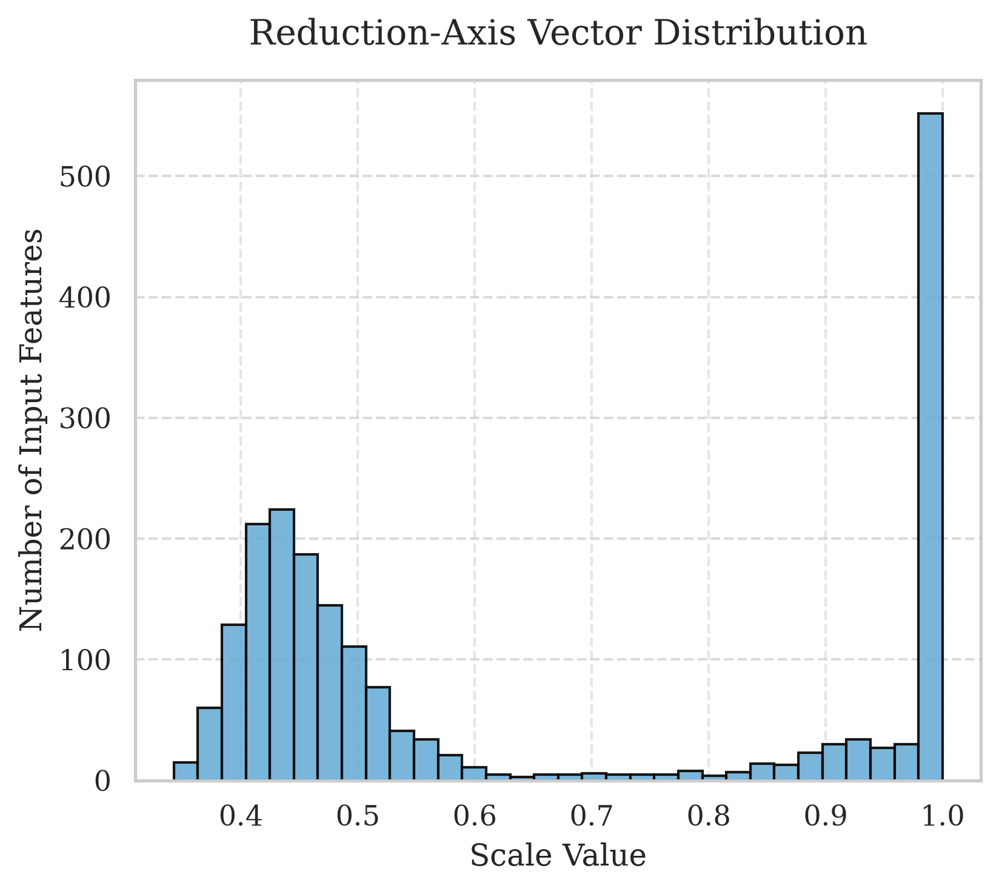

In [24]:
# Visualization
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.hist(
    v_np,
    bins=32,
    color=PALETTE[1],
    edgecolor="black",
    linewidth=1.0,
    alpha=0.9
)

ax.set_title("Reduction-Axis Vector Distribution", fontsize=14, pad=14)
ax.set_xlabel("Scale Value", fontsize=12)
ax.set_ylabel("Number of Input Features", fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.grid(axis='y', linestyle='--', alpha=0.7)

save_figure(fig, "2d_reduction_axis_vector_distribution")
plt.show()

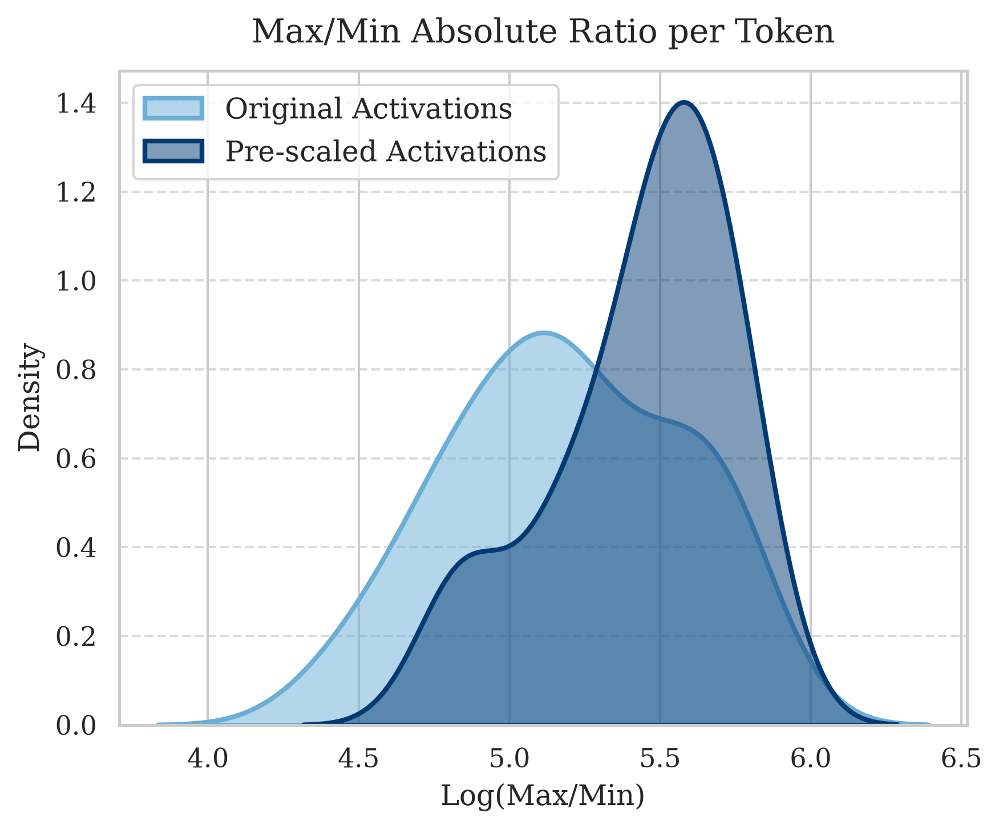

In [25]:
# Pre-scale activations by the reduction-axis vector
A_tilde = A * v_vec.unsqueeze(0)

# Compute absolute values
A_abs = A.abs()
A_tilde_abs = A_tilde.abs()

eps = 1e-7

# Max/Min absolute ratio per token
min_before = torch.clamp(A_abs.min(dim=1)[0], min=eps)
min_after = torch.clamp(A_tilde_abs.min(dim=1)[0], min=eps)
max_min_before = (A_abs.max(dim=1)[0] / min_before).cpu().numpy()
max_min_after = (A_tilde_abs.max(dim=1)[0] / min_after).cpu().numpy()

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

sns.kdeplot(
    np.log10(max_min_before),
    color=PALETTE[1],
    fill=True,
    alpha=0.5,
    linewidth=2,
    label="Original Activations",
    ax=ax
)
sns.kdeplot(
    np.log10(max_min_after),
    color=PALETTE[4],
    fill=True,
    alpha=0.5,
    linewidth=2,
    label="Pre-scaled Activations",
    ax=ax
)

ax.set_title("Max/Min Absolute Ratio per Token", fontsize=14, pad=12)
ax.set_xlabel("Log(Max/Min)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
save_figure(fig, "2e_activation_outlier_impact")
plt.show()

### Analyzing Optimal Clusterization Technique

In [26]:
# Configuration
TARGET_LAYER = "o_proj"
TARGET_AXIS = "rows"
BIT_WIDTH = 4

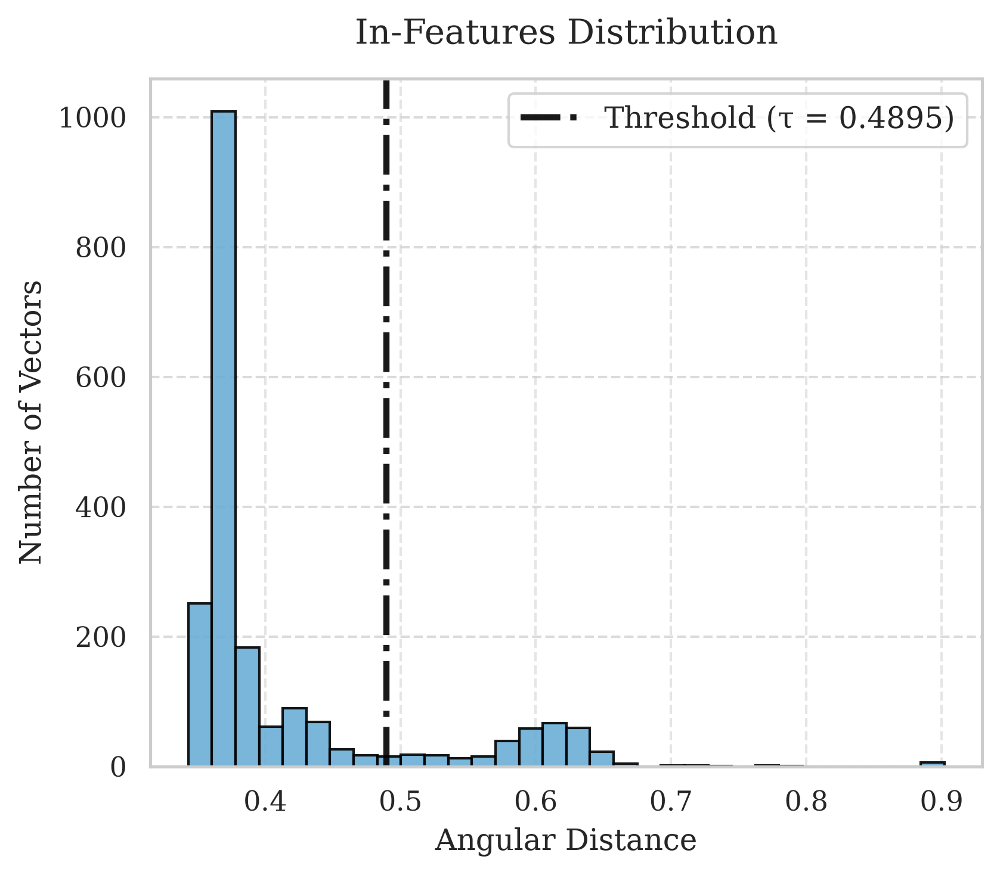

In [27]:
from lrsr.utils import compute_otsu_threshold
from lrsr.metrics import compute_median_angular_distances


# Load weights
file_path = layer_groups[TARGET_LAYER][0]
data = torch.load(file_path, weights_only=False)
W = data['W'].to(torch.float32)
qmax = get_qmax(BIT_WIDTH)

# Build per-element scales
S_ideal = torch.clamp(W.abs() / qmax, min=1e-7)

# Compute angular distances for rows and columns
dist_rows = compute_median_angular_distances(S_ideal.T).cpu().numpy()
dist_cols = compute_median_angular_distances(S_ideal).cpu().numpy()

# Compute thresholds for optimal binary separation
tau_rows = compute_otsu_threshold(dist_rows)
tau_cols = compute_otsu_threshold(dist_cols)

# Select data for visualiation
if TARGET_AXIS == "rows":
    dist = dist_rows
    tau = tau_rows
    title = "In-Features Distribution"
elif TARGET_AXIS == "columns":
    dist = dist_cols
    tau = tau_cols
    title = "Out-Features Distribution"
else:
    raise ValueError(f"Unsupported target axis: {TARGET_AXIS}")

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.hist(
    dist,
    bins=32,
    color=PALETTE[1],
    edgecolor="black",
    linewidth=1.0,
    alpha=0.9
)

ax.axvline(
    tau,
    color='black',
    linestyle='-.',
    linewidth=2.5,
    alpha=0.9,
    label=f'Threshold (τ = {tau:.4f})'
)

ax.set_title(title, fontsize=14, pad=14)
ax.set_xlabel("Angular Distance", fontsize=12)
ax.set_ylabel("Number of Vectors", fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.legend(loc="upper right", fontsize=12)

save_figure(fig, "3a_angular_distance_distribution")
plt.show()


In [28]:
# Configuration
VIS_BINS_MAIN = (128, 192)
VIS_BINS_MINOR = (128, 64)

In [29]:
# Split by columns
labels_cols = np.where(dist_cols > tau_cols, 1, 0)
idx_c_main = np.where(labels_cols == 0)[0]
idx_c_minor = np.where(labels_cols == 1)[0]

S_main = S_ideal[:, idx_c_main]
S_minor = S_ideal[:, idx_c_minor]

# Make Low-Rank Approximations
S_approx_main = torch.clamp(rank_approximator.approximate(S_main, rank=1), min=1e-7)
S_approx_minor = torch.clamp(rank_approximator.approximate(S_minor, rank=1), min=1e-7)

# Compute Errors
Err_main = S_approx_main - S_main
Err_minor = S_approx_minor - S_minor

print(f"Total Columns: {S_ideal.shape[1]}")
print(f"Major Cluster: {len(idx_c_main)} columns ({(len(idx_c_main)/S_ideal.shape[1])*100:.1f}%)")
print(f"Minor Cluster: {len(idx_c_minor)} columns ({(len(idx_c_minor)/S_ideal.shape[1])*100:.1f}%)")

Total Columns: 2048
Major Cluster: 1757 columns (85.8%)
Minor Cluster: 291 columns (14.2%)


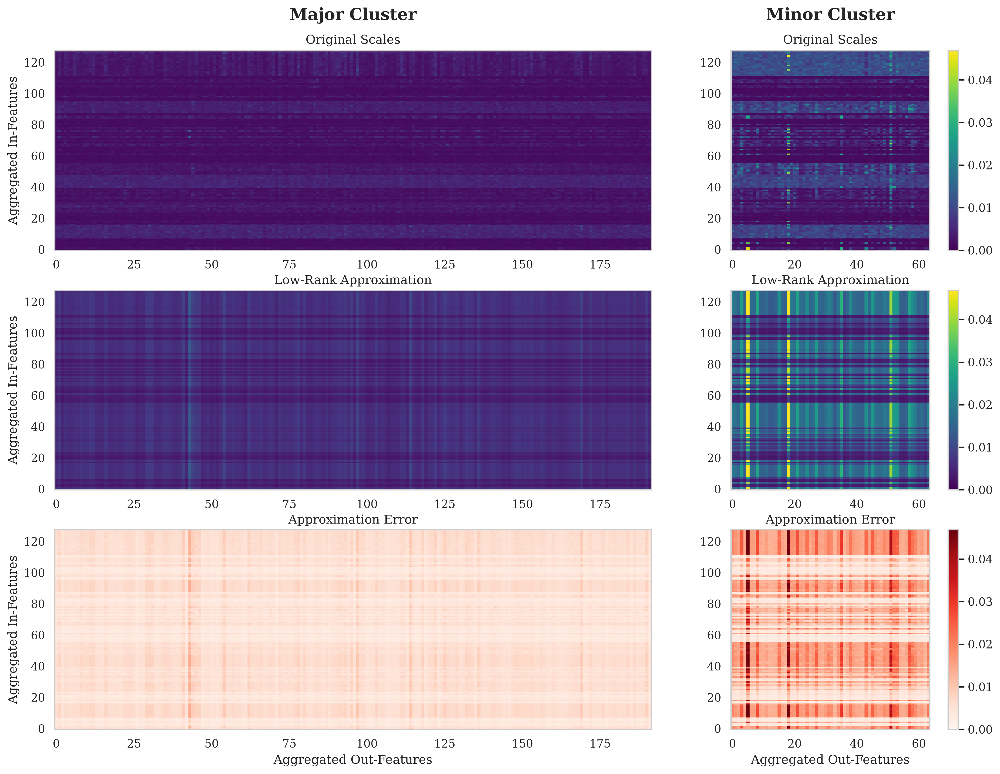

In [30]:
# Aggregate for visualization
agg_S_main = aggregate_matrix(S_main.cpu().numpy(), VIS_BINS_MAIN, ('max', 'max'))
agg_S_minor = aggregate_matrix(S_minor.cpu().numpy(), VIS_BINS_MINOR, ('max', 'max'))

agg_A_main = aggregate_matrix(S_approx_main.cpu().numpy(), VIS_BINS_MAIN, ('max', 'max'))
agg_A_minor = aggregate_matrix(S_approx_minor.cpu().numpy(), VIS_BINS_MINOR, ('max', 'max'))

agg_E_main = aggregate_matrix(Err_main.cpu().numpy(), VIS_BINS_MAIN, ('max', 'max'))
agg_E_minor = aggregate_matrix(Err_minor.cpu().numpy(), VIS_BINS_MINOR, ('max', 'max'))

# Prepare global max for scales and errors
vmax_scale = max(agg_S_main.max(), agg_S_minor.max())
vmax_err = max(np.max(np.abs(agg_E_main)), np.max(np.abs(agg_E_minor)))

# Visualization
fig, axes = plt.subplots(3, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [3, 1]})

# Original Scales
im0 = axes[0, 0].imshow(agg_S_main, cmap="viridis", aspect="auto", origin="lower", vmin=0, vmax=vmax_scale)
axes[0, 0].set_title("Major Cluster", fontsize=16, fontweight="bold", pad=30)
axes[0, 0].text(0.5, 1.02, "Original Scales", transform=axes[0, 0].transAxes, ha="center", va="bottom", fontsize=12)
axes[0, 0].set_ylabel("Aggregated In-Features", fontsize=12)
axes[0, 0].grid(False)

im1 = axes[0, 1].imshow(agg_S_minor, cmap="viridis", aspect="auto", origin="lower", vmin=0, vmax=vmax_scale)
axes[0, 1].set_title("Minor Cluster", fontsize=16, fontweight="bold", pad=30)
axes[0, 1].text(0.5, 1.02, "Original Scales", transform=axes[0, 1].transAxes, ha="center", va="bottom", fontsize=12)
axes[0, 1].grid(False)
fig.colorbar(im1, ax=axes[0, :].ravel().tolist(), fraction=0.02, pad=0.02)

# Low-Rank Approximations
axes[1, 0].imshow(agg_A_main, cmap="viridis", aspect="auto", origin="lower", vmin=0, vmax=vmax_scale)
axes[1, 0].set_title("Low-Rank Approximation", fontsize=12)
axes[1, 0].set_ylabel("Aggregated In-Features", fontsize=12)
axes[1, 0].grid(False)

im2 = axes[1, 1].imshow(agg_A_minor, cmap="viridis", aspect="auto", origin="lower", vmin=0, vmax=vmax_scale)
axes[1, 1].set_title("Low-Rank Approximation", fontsize=12)
axes[1, 1].grid(False)
fig.colorbar(im2, ax=axes[1, :].ravel().tolist(), fraction=0.02, pad=0.02)

# Aprroximation Errors
axes[2, 0].imshow(agg_E_main, cmap="Reds", aspect="auto", origin="lower", vmin=0, vmax=vmax_err)
axes[2, 0].set_title("Approximation Error", fontsize=12)
axes[2, 0].set_ylabel("Aggregated In-Features", fontsize=12)
axes[2, 0].set_xlabel("Aggregated Out-Features", fontsize=12)
axes[2, 0].grid(False)

im3 = axes[2, 1].imshow(agg_E_minor, cmap="Reds", aspect="auto", origin="lower", vmin=0, vmax=vmax_err)
axes[2, 1].set_title("Approximation Error", fontsize=12)
axes[2, 1].set_xlabel("Aggregated Out-Features", fontsize=12)
axes[2, 1].grid(False)
fig.colorbar(im3, ax=axes[2, :].ravel().tolist(), fraction=0.02, pad=0.02)

save_figure(fig, "3b_1d_outlier_separation_lrsr")
plt.show()

In [31]:
# Configuration
VIS_BINS = (128, 256)

In [32]:
# Split by rows
labels_rows = np.where(dist_rows > tau_rows, 1, 0)
idx_r_main = np.where(labels_rows == 0)[0]
idx_r_minor = np.where(labels_rows == 1)[0]

S_approx_2d = torch.zeros_like(S_ideal)

def approximate_quadrant(r_idx, c_idx):
    """Approximates quadrant based on provided indices."""
    if len(r_idx) > 0 and len(c_idx) > 0:
        sub_S = S_ideal[np.ix_(r_idx, c_idx)]
        sub_A = torch.clamp(rank_approximator.approximate(sub_S, rank=1), min=1e-7)
        S_approx_2d[np.ix_(r_idx, c_idx)] = sub_A

approximate_quadrant(idx_r_main, idx_c_main)
approximate_quadrant(idx_r_main, idx_c_minor)
approximate_quadrant(idx_r_minor, idx_c_main)
approximate_quadrant(idx_r_minor, idx_c_minor)

Err_2d = S_approx_2d - S_ideal

def aggregate_quadrants(matrix_np: np.ndarray, method: str = 'max') -> tuple:
    """Aggregates 4 quadrants and creates a reordered matrix."""
    tot_r = len(idx_r_main) + len(idx_r_minor)
    tot_c = len(idx_c_main) + len(idx_c_minor)

    # Calculate proportional bins
    br_maj = max(16, int(VIS_BINS[0] * len(idx_r_main) / tot_r))
    br_min = max(16, VIS_BINS[0] - br_maj)
    bc_maj = max(16, int(VIS_BINS[1] * len(idx_c_main) / tot_c))
    bc_min = max(16, VIS_BINS[1] - bc_maj)

    # Extract quadrants
    q_maj_maj = matrix_np[np.ix_(idx_r_main, idx_c_main)]
    q_maj_min = matrix_np[np.ix_(idx_r_main, idx_c_minor)]
    q_min_maj = matrix_np[np.ix_(idx_r_minor, idx_c_main)]
    q_min_min = matrix_np[np.ix_(idx_r_minor, idx_c_minor)]

    # Aggregate data
    def _agg(sub, shape):
        actual_shape = (min(shape[0], sub.shape[0]), min(shape[1], sub.shape[1]))
        return aggregate_matrix(sub, actual_shape, (method, method))

    agg_00 = _agg(q_maj_maj, (br_maj, bc_maj))
    agg_01 = _agg(q_maj_min, (br_maj, bc_min))
    agg_10 = _agg(q_min_maj, (br_min, bc_maj))
    agg_11 = _agg(q_min_min, (br_min, bc_min))

    # Stitch bottom row and top row
    bottom_block = np.hstack([agg_00, agg_01])
    top_block    = np.hstack([agg_10, agg_11])
    reordered_agg = np.vstack([bottom_block, top_block])

    sep_row = agg_00.shape[0]
    sep_col = agg_00.shape[1]

    return reordered_agg, sep_row, sep_col

# Aggregate data
S_ideal_agg, sep_r, sep_c = aggregate_quadrants(S_ideal.cpu().numpy(), method='max')
S_approx_agg, _, _        = aggregate_quadrants(S_approx_2d.cpu().numpy(), method='max')
Err_agg, _, _             = aggregate_quadrants(Err_2d.cpu().numpy(), method='max')

vmax_scale = max(S_ideal_agg.max(), S_approx_agg.max())
vmax_err = np.max(np.abs(Err_agg))

print(f"Total Shape: {S_ideal.shape[0]} rows x {S_ideal.shape[1]} cols")
print(f"Row Split:   Major {len(idx_r_main)}, Minor {len(idx_r_minor)}")
print(f"Col Split:   Major {len(idx_c_main)}, Minor {len(idx_c_minor)}")

Total Shape: 2048 rows x 2048 cols
Row Split:   Major 1714, Minor 334
Col Split:   Major 1757, Minor 291


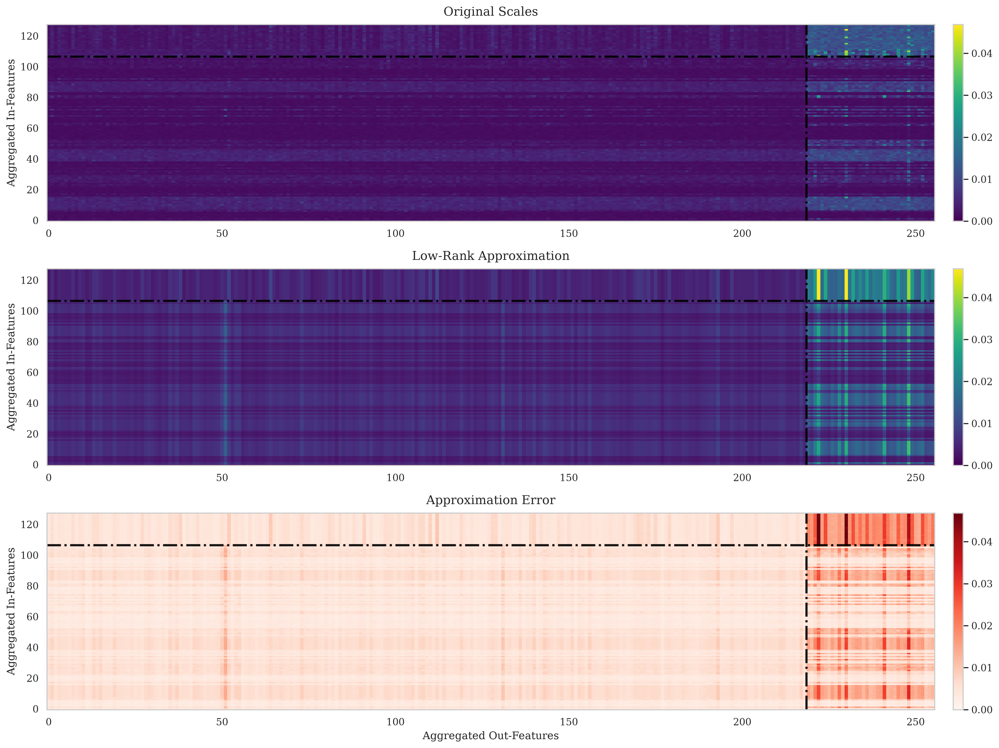

In [33]:
# Visualization
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

matrices = [
    (S_ideal_agg, "Original Scales", "viridis", 0, vmax_scale),
    (S_approx_agg, "Low-Rank Approximation", "viridis", 0, vmax_scale),
    (Err_agg, "Approximation Error", "Reds", 0, vmax_err)
]

total_rows, total_cols = S_ideal_agg.shape

for i, ax in enumerate(axes):
    data, title, cmap, vmin, vmax = matrices[i]

    im = ax.imshow(data, cmap=cmap, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_ylabel("Aggregated In-Features", fontsize=12)
    if i == 2:
        ax.set_xlabel("Aggregated Out-Features", fontsize=12)

    ax.grid(False)

    ax.axhline(sep_r - 0.5, color='black', linestyle='-.', linewidth=2.5, alpha=0.9)
    ax.axvline(sep_c - 0.5, color='black', linestyle='-.', linewidth=2.5, alpha=0.9)

    text_kwargs = dict(
        color='gray',
        ha='center',
        va='center',
        fontweight='bold',
        fontsize=13
    )

    fig.colorbar(im, ax=ax, fraction=0.015, pad=0.02)

plt.tight_layout()
save_figure(fig, "3c_2d_outlier_separation_lrsr")
plt.show()

In [34]:
# Configuration
VIS_BINS = (128, 128)

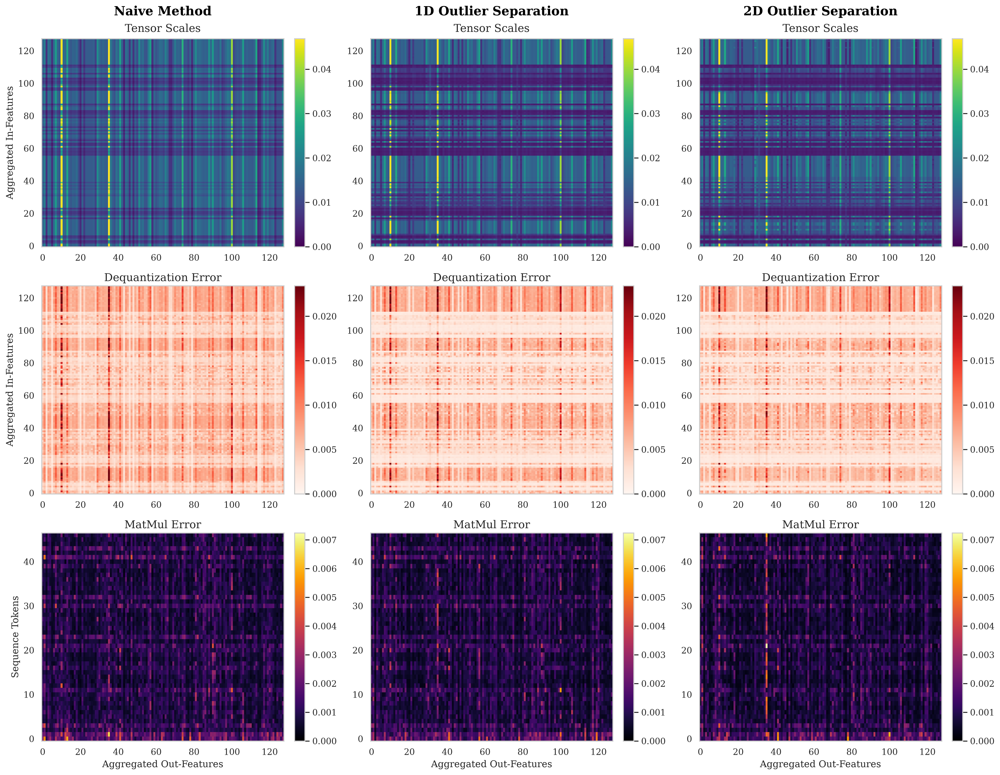

In [35]:
# Assemble full matrix for 1D Outlier Separation
S_c_lrsr = torch.zeros_like(S_ideal)
S_c_lrsr[:, idx_c_main] = S_approx_main
S_c_lrsr[:, idx_c_minor] = S_approx_minor
S_c_lrsr = torch.clamp(S_c_lrsr, min=1e-7)

S_g_lrsr = torch.clamp(S_approx_2d, min=1e-7)

# Compute Quantization Errors
Err_W_t, W_dq_t = compute_weight_error(W, S_lrsr, qmax)
Err_W_c, W_dq_c = compute_weight_error(W, S_c_lrsr, qmax)
Err_W_g, W_dq_g = compute_weight_error(W, S_g_lrsr, qmax)

# Compute MatMul Errors
with torch.no_grad():
    Err_Y_t = torch.abs(Y_true - torch.matmul(A, W_dq_t))
    Err_Y_c = torch.abs(Y_true - torch.matmul(A, W_dq_c))
    Err_Y_g = torch.abs(Y_true - torch.matmul(A, W_dq_g))

# Aggregate matrices
scales_row_final = [agg(S_lrsr, VIS_BINS), agg(S_c_lrsr, VIS_BINS), agg(S_g_lrsr, VIS_BINS)]
weights_row_final = [agg(Err_W_t, VIS_BINS), agg(Err_W_c, VIS_BINS), agg(Err_W_g, VIS_BINS)]
matmul_row_final = [agg(Err_Y_t, VIS_BINS), agg(Err_Y_c, VIS_BINS), agg(Err_Y_g, VIS_BINS)]

# Visualization
col_titles_final = [
    "Naive Method",
    "1D Outlier Separation",
    "2D Outlier Separation"
]
row_ylabels_final = [
    "Aggregated In-Features",
    "Aggregated In-Features",
    "Sequence Tokens"
]

plot_error_analysis(
    col_titles=col_titles_final,
    row_data=[scales_row_final, weights_row_final, matmul_row_final],
    row_ylabels=row_ylabels_final,
    save_name="3d_outlier_separation_error_analysis"
)

In [36]:
# Configuration
TARGET_LAYER = "o_proj"
BIT_WIDTH = 4
NUM_CLUSTERS = 3
TOLERANCE = 0.05

In [37]:
from sklearn.cluster import KMeans

from lrsr.clusterization.kmeans_clusterization import KMeansClusterization


# Load data and ideal parameters
file_path = layer_groups[TARGET_LAYER][0]
data = torch.load(file_path, weights_only=False)
W = data['W'].to(torch.float32)

qmax = get_qmax(BIT_WIDTH)
W_var = torch.var(W).item()
S_ideal = torch.clamp(W.abs() / qmax, min=1e-7)
K_dim, N_dim = S_ideal.shape

def evaluate_clustering(labels: np.ndarray, num_clusters: int, name: str) -> dict:
    S_approx_full = torch.zeros_like(S_ideal)
    cluster_sizes = []

    # Approximate each cluster
    for c_idx in range(num_clusters):
        indices = np.where(labels == c_idx)[0]
        cluster_sizes.append(len(indices))
        if len(indices) == 0:
            continue

        sub_S = S_ideal[:, indices]
        sub_A = torch.clamp(rank_approximator.approximate(sub_S, rank=1), min=1e-7)
        S_approx_full[:, indices] = sub_A

    # Calculate error
    W_dq = torch.clamp(torch.round(W / S_approx_full), -qmax, qmax) * S_approx_full
    nmse_val = mse(W, W_dq) / W_var

    return {"Method": name, "NMSE": nmse_val, "Sizes": cluster_sizes}

all_results = []

# Naive Chunking
labels_naive = np.zeros(N_dim, dtype=int)
for i, chunk in enumerate(np.array_split(np.arange(N_dim), NUM_CLUSTERS)):
    labels_naive[chunk] = i
all_results.append(evaluate_clustering(labels_naive, NUM_CLUSTERS, "Naive Chunking"))

# Standard Spherical K-Means
S_norm_np = (S_ideal / torch.norm(S_ideal, dim=0, keepdim=True)).cpu().numpy()
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=0, n_init=10)
labels_kmeans = kmeans.fit_predict(S_norm_np.T)
all_results.append(evaluate_clustering(labels_kmeans, NUM_CLUSTERS, "Standard K-Means"))

# Constrained K-Means
constrained_kmeans = KMeansClusterization(tolerance=TOLERANCE)
constrained_kmeans.fit(S_ideal)
labels_bradley = constrained_kmeans.predict(NUM_CLUSTERS)
all_results.append(evaluate_clustering(labels_bradley, NUM_CLUSTERS, "Constrained K-Means"))

df_splits = pd.DataFrame(all_results)
print(df_splits.to_string())

                Method      NMSE             Sizes
0       Naive Chunking  0.029274   [683, 683, 682]
1     Standard K-Means  0.022541  [1659, 278, 111]
2  Constrained K-Means  0.026916   [683, 717, 648]


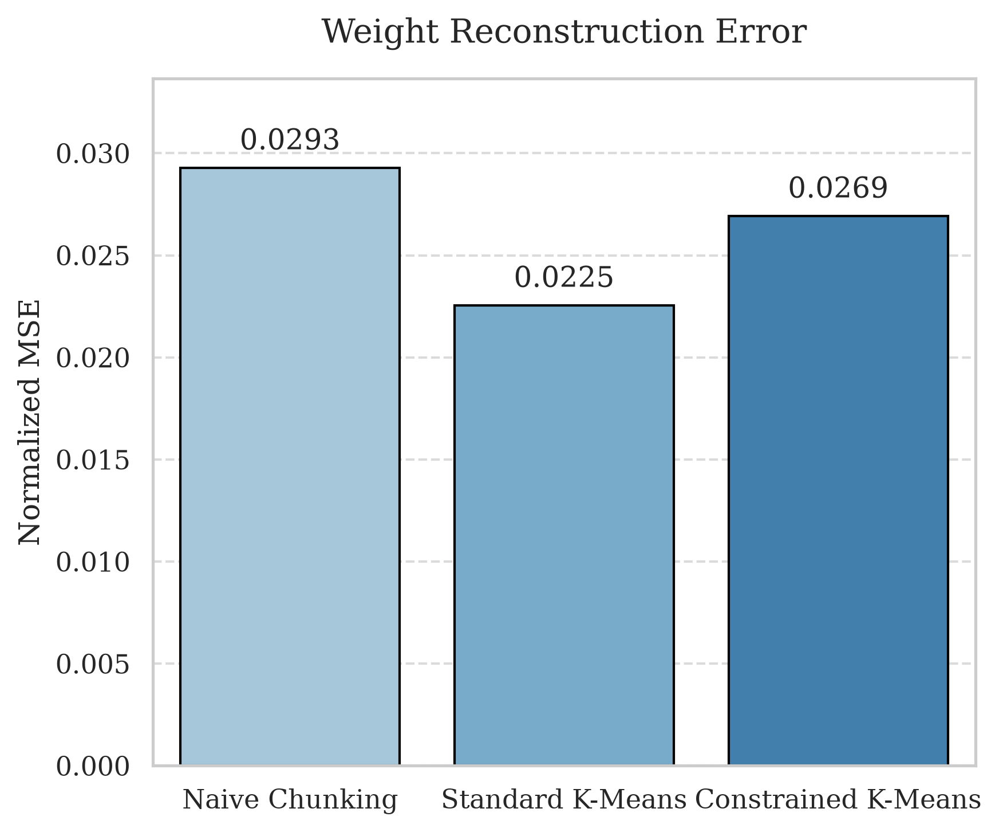

In [38]:
# Visualization
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

sns.barplot(
    data=df_splits, x="Method", y="NMSE", hue="Method",
    palette=PALETTE[:3], edgecolor="black", linewidth=1.0, ax=ax
)

ax.set_title(f"Weight Reconstruction Error", fontsize=14, pad=15)
ax.set_ylabel("Normalized MSE", fontsize=12)
ax.set_xlabel("")
ax.grid(axis="y", linestyle="--", alpha=0.7)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

y_max = df_splits["NMSE"].max() * 1.15
ax.set_ylim(0, y_max)

plt.tight_layout()
save_figure(fig, "3e_weight_reconstruction_error_kmeans")
plt.show()

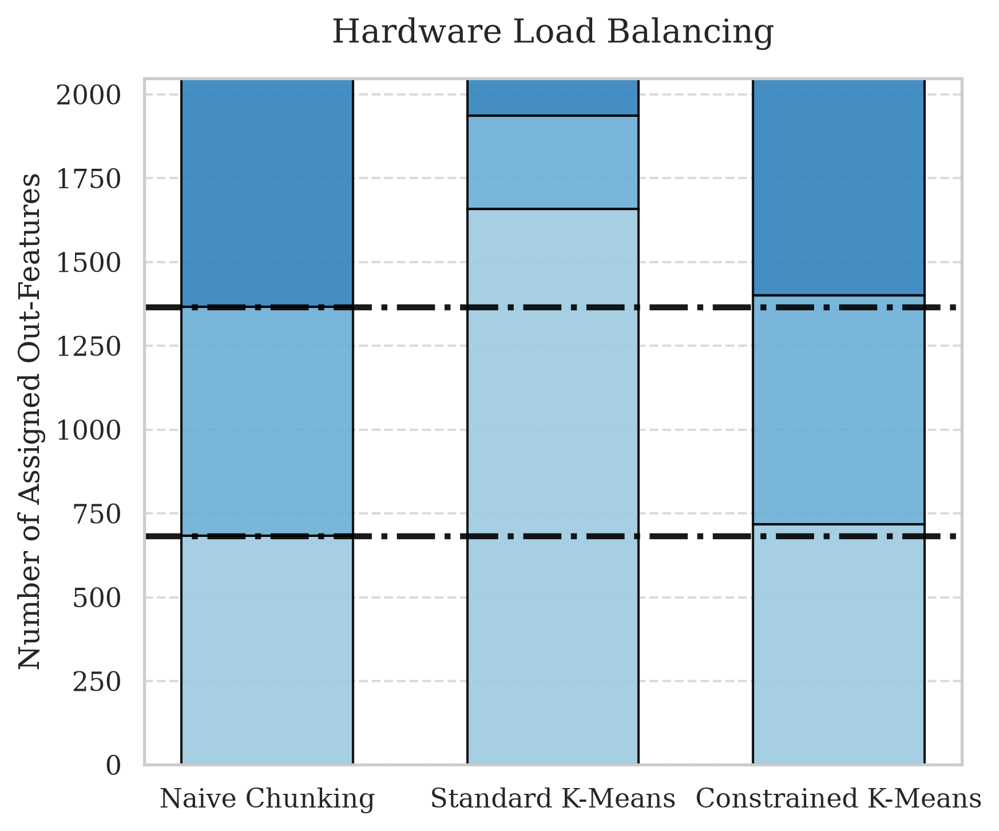

In [39]:
# Visualization
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

bottom = np.zeros(len(df_splits))
for core_idx in range(NUM_CLUSTERS):
    sizes = [sorted(row["Sizes"], reverse=True)[core_idx] for _, row in df_splits.iterrows()]
    ax.bar(
        df_splits["Method"], sizes, bottom=bottom,
        color=PALETTE[core_idx],
        edgecolor="black", linewidth=1.0, alpha=0.9, width=0.6
    )
    bottom += np.array(sizes)

ax.set_ylim(0, N_dim)
ax.margins(y=0)

ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle="--", alpha=0.7, zorder=1)

target_size = N_dim / NUM_CLUSTERS
for i in range(1, NUM_CLUSTERS):
    ax.axhline(target_size * i, color="black", linestyle="-.", alpha=0.9, linewidth=2.5)

ax.set_title(f"Hardware Load Balancing", fontsize=14, pad=15)
ax.set_ylabel("Number of Assigned Out-Features", fontsize=12)
ax.set_xlabel("")

plt.tight_layout()
save_figure(fig, "3f_hardware_load_balancing_kmeans")
plt.show()

### Visualizing End-To-End benchmark results

In [40]:
RESULTS_FILE = Path("../benchmarks/layer/result/results.json")
assert RESULTS_FILE.exists(), f"Layer benchmark results file not found: {RESULTS_FILE.resolve()}"

In [41]:
# Configuration
METHOD_NAMES = {
    'gap_lrsr-naive': 'LRSR-Naive',
    'gap_lrsr-1dos': 'LRSR-1DOS',
    'gap_lrsr-kmeans': 'LRSR-KMeans'
}

In [42]:
import json


with open(RESULTS_FILE, "r") as f:
    eval_data = json.load(f)

# Flatten JSON into a list of records
records = []
for file_record in eval_data["files"]:
    row = {
        "model": file_record["model"],
        "model_short": file_record["model"].split("/")[-1],
        "layer": file_record["layer"],
        "layer_type": file_record["layer"].split(".")[-1],
        "prompt": file_record["prompt"]
    }
    for method, nmse_val in file_record["nmse"].items():
        row[f"nmse_{method}"] = nmse_val
    records.append(row)

df_eval = pd.DataFrame(records)

# Calculate Gap Closed for each method
df_eval['gap_total'] = df_eval['nmse_per-channel'] - df_eval['nmse_per-group']
for m in ['lrsr-naive', 'lrsr-1dos', 'lrsr-kmeans']:
    df_eval[f'gap_{m}'] = np.where(
        df_eval['gap_total'] > 0,
        (df_eval['nmse_per-channel'] - df_eval[f'nmse_{m}']) / df_eval['gap_total'] * 100.0,
        0.0
    )

print(f"Loaded {len(df_eval)} benchmark records.")

Loaded 115 benchmark records.


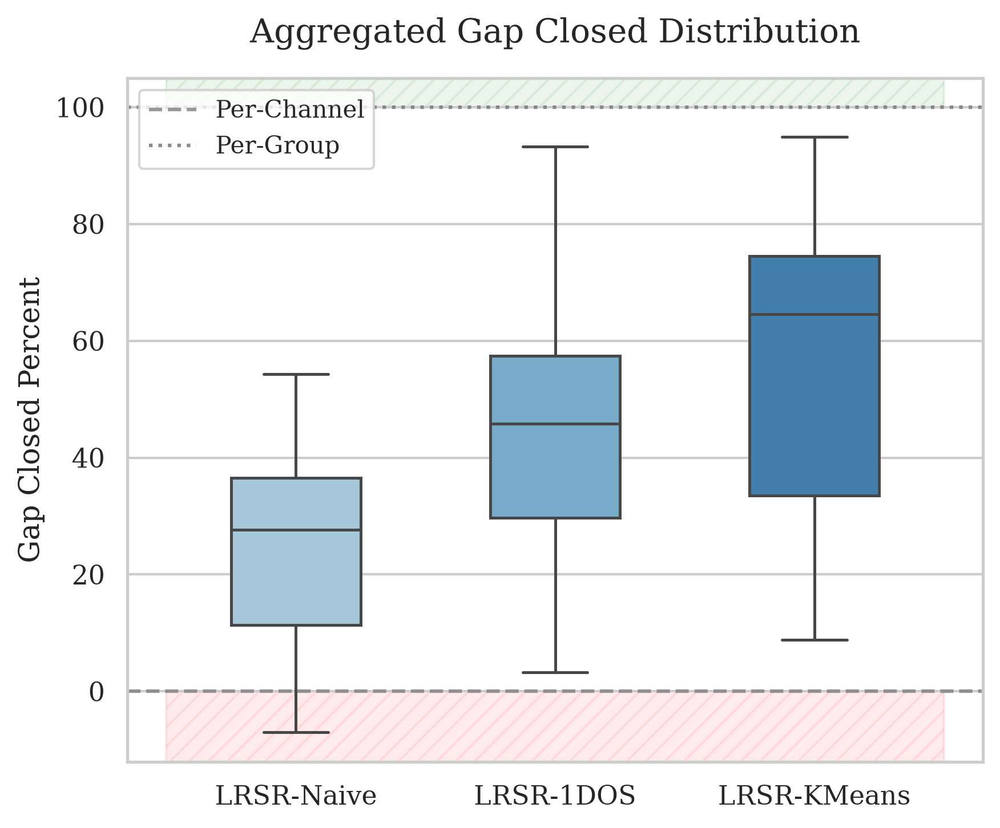

In [43]:
# Melt dataframe for seaborn boxplot
df_box = df_eval.melt(
    id_vars=['model', 'layer_type', 'prompt'],
    value_vars=['gap_lrsr-naive', 'gap_lrsr-1dos', 'gap_lrsr-kmeans'],
    var_name='Method',
    value_name='Gap Closed'
)
df_box['Method'] = df_box['Method'].map(METHOD_NAMES)

# Visualization
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=df_box,
    x='Method',
    y='Gap Closed',
    hue='Method',
    palette=PALETTE[:3],
    width=0.5,
    linewidth=1.2,
    showfliers=False,
    ax=ax
)

ax.set_title("Aggregated Gap Closed Distribution", fontsize=14, pad=15)
ax.set_xlabel("")
ax.set_ylabel("Gap Closed Percent", fontsize=12)

# Baselines
line_pc = ax.axhline(0, color='gray', linestyle='--', alpha=0.8)
line_pg = ax.axhline(100, color='gray', linestyle=':', alpha=0.9)

y_min, y_max = ax.get_ylim()
ax.set_ylim(min(y_min, -5), max(y_max, 105))

# Shade regions
shade_bounds(
    ax,
    x=[-0.5, 2.5],
    upper_y=100.0,
    lower_y=0.0,
    upper_color="green",
    lower_color="red"
)

ax.legend([line_pc, line_pg], ["Per-Channel", "Per-Group"], loc='upper left', fontsize=10)

plt.tight_layout()
save_figure(fig, "4a_gap_closed_distribution_lrsr")
plt.show()

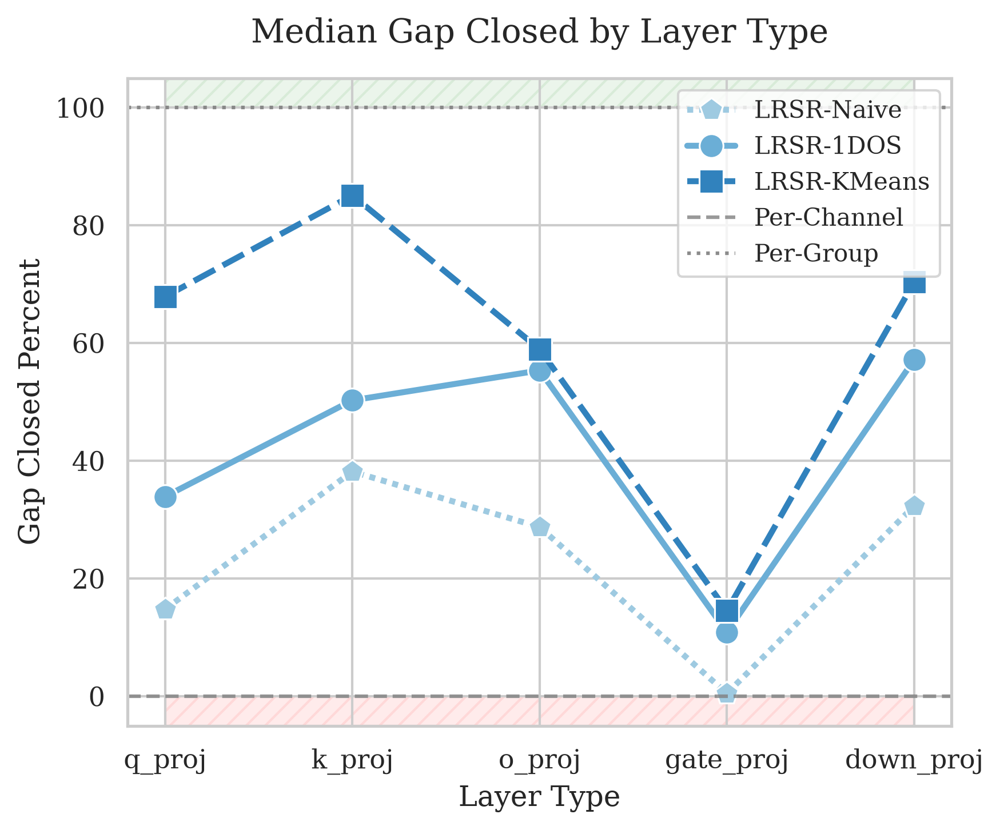

In [44]:
# Group by layer type
df_line = df_box.groupby(['Method', 'layer_type'])['Gap Closed'].median().reset_index()

# Define a logical order for layer types
order = ['q_proj', 'k_proj', 'o_proj', 'gate_proj', 'down_proj']
df_line['layer_type'] = pd.Categorical(df_line['layer_type'], categories=order, ordered=True)
df_line = df_line.sort_values('layer_type')

# Visualization
fig, ax = plt.subplots(figsize=(6, 5))

sns.lineplot(
    data=df_line,
    x='layer_type',
    y='Gap Closed',
    hue='Method',
    style='Method',
    markers=MARKERS[:3],
    palette=PALETTE[:3],
    linewidth=2.5,
    markersize=10,
    ax=ax,
    hue_order=['LRSR-Naive', 'LRSR-1DOS', 'LRSR-KMeans']
)

ax.set_title("Median Gap Closed by Layer Type", fontsize=14, pad=15)
ax.set_xlabel("Layer Type", fontsize=12)
ax.set_ylabel("Gap Closed Percent", fontsize=12)

# Baselines
line_pc = ax.axhline(0, color='gray', linestyle='--', alpha=0.8)
line_pg = ax.axhline(100, color='gray', linestyle=':', alpha=0.9)

y_min, y_max = ax.get_ylim()
ax.set_ylim(min(-5, y_min), max(105, y_max))

# Shade regions
shade_bounds(
    ax,
    x=[0, len(order)-1],
    upper_y=100.0,
    lower_y=0.0,
    upper_color="green",
    lower_color="red"
)

handles, labels = ax.get_legend_handles_labels()
handles.extend([line_pc, line_pg])
labels.extend(["Per-Channel", "Per-Group"])

ax.legend(handles=handles, labels=labels, loc="upper right", fontsize=10)

plt.tight_layout()
save_figure(fig, "4b_gap_closed_by_layer_type")
plt.show()

In [45]:
# Configuration
TARGET_METHOD = 'gap_lrsr-kmeans' # 'gap_lrsr-naive' | 'gap_lrsr-1dos' | 'gap_lrsr-kmeans'

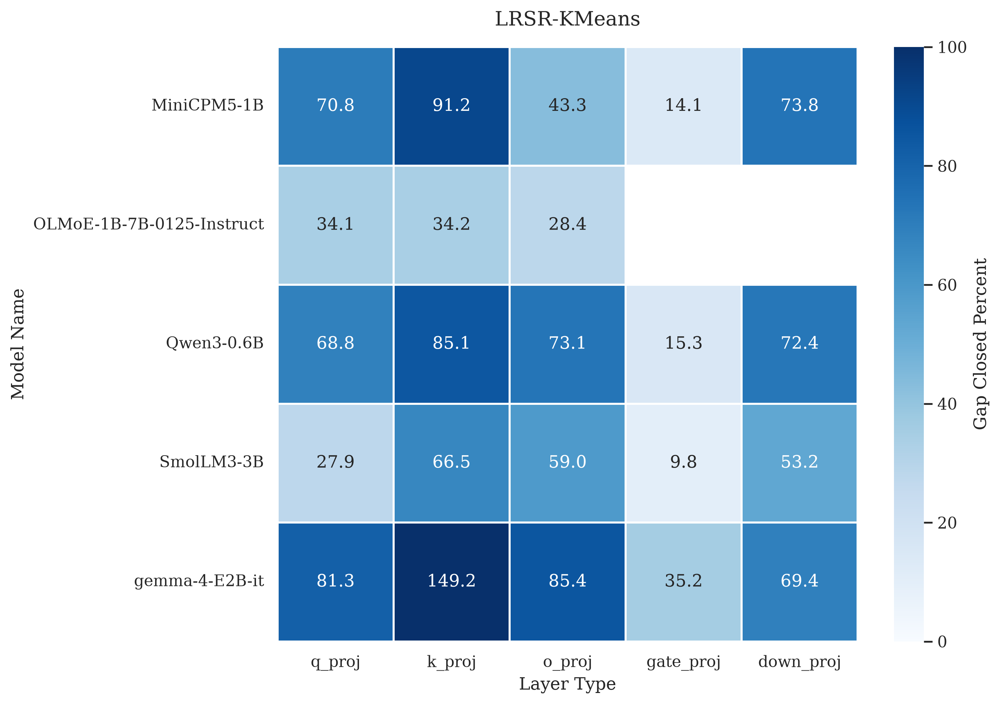

In [46]:
# Group by model and layer
df_heatmap = df_eval.groupby(['model_short', 'layer_type'])[TARGET_METHOD].median().unstack()

# Define a logical order for layer types
existing_cols = [col for col in order if col in df_heatmap.columns]
df_heatmap = df_heatmap[existing_cols]

# Visualization
fig, ax = plt.subplots(figsize=(10, 7))

ax.grid(False)
ax.set_facecolor("white")

sns.heatmap(
    df_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=1.0,
    linecolor='white',
    cbar_kws={'label': 'Gap Closed Percent'},
    ax=ax
)

ax.set_title(f"{METHOD_NAMES[TARGET_METHOD]}", fontsize=14, pad=15)
ax.set_xlabel("Layer Type", fontsize=12)
ax.set_ylabel("Model Name", fontsize=12)

plt.yticks(rotation=0)

plt.tight_layout()
save_figure(fig, f"4c_modelxlayer_gap_closed")
plt.show()

In [47]:
RESULTS_FILE = Path("../benchmarks/logits/result/results.json")
assert RESULTS_FILE.exists(), f"Logits benchmark results file not found: {RESULTS_FILE.resolve()}"

In [48]:
# Configuration
METHOD_NAMES = {
    "per-channel": "Per-Channel",
    "per-group": "Per-Group",
    "lrsr-naive": "LRSR-Naive",
    "lrsr-1dos": "LRSR-1DOS",
    "lrsr-kmeans": "LRSR-KMeans",
}

In [49]:
with open(RESULTS_FILE, "r") as f:
    logits_data = json.load(f)

# Flatten JSON records
records = []
for record in logits_data["records"]:
    records.append({
        "model": record["model"],
        "method": record["method"],
        "bits": record["bits"],
        "mean_kld": record["metrics"]["mean_kld"],
        "same_top_1": record["metrics"]["same_top_1"],
    })

df_logits = pd.DataFrame(records)

print(f"Loaded {len(df_logits)} benchmark records.")

Loaded 20 benchmark records.


In [50]:
def dynamic_ylim(ax: plt.Axes, values, margin: float = 0.1) -> None:
    """Sets y-limits with a relative margin around the data range."""
    vmin, vmax = float(np.min(values)), float(np.max(values))
    span = vmax - vmin
    if span == 0:
        span = abs(vmax) * margin if vmax != 0 else 1.0
    ax.set_ylim(vmin - margin * span, vmax + margin * span)

In [51]:
# Configuration
TARGET_MODEL = "Qwen/Qwen3-4B"
BIT_WIDTH = 4
TARGET_METHODS = ["per-channel", "per-group", "lrsr-naive", "lrsr-1dos", "lrsr-kmeans"]

In [52]:
# Filter configuration from the dataset
mask = (
    (df_logits["model"] == TARGET_MODEL)
    & (df_logits["bits"] == BIT_WIDTH)
    & (df_logits["method"].isin(TARGET_METHODS))
)
df_filtered = df_logits[mask].copy()
df_filtered["__order"] = df_filtered["method"].map({m: i for i, m in enumerate(TARGET_METHODS)})
df_filtered = df_filtered.sort_values("__order").drop(columns="__order").reset_index(drop=True)
df_filtered["method_display"] = df_filtered["method"].map(METHOD_NAMES)

# Save short model title
model_short = TARGET_MODEL.split("/")[-1]
title = f"{model_short} (INT{BIT_WIDTH})"

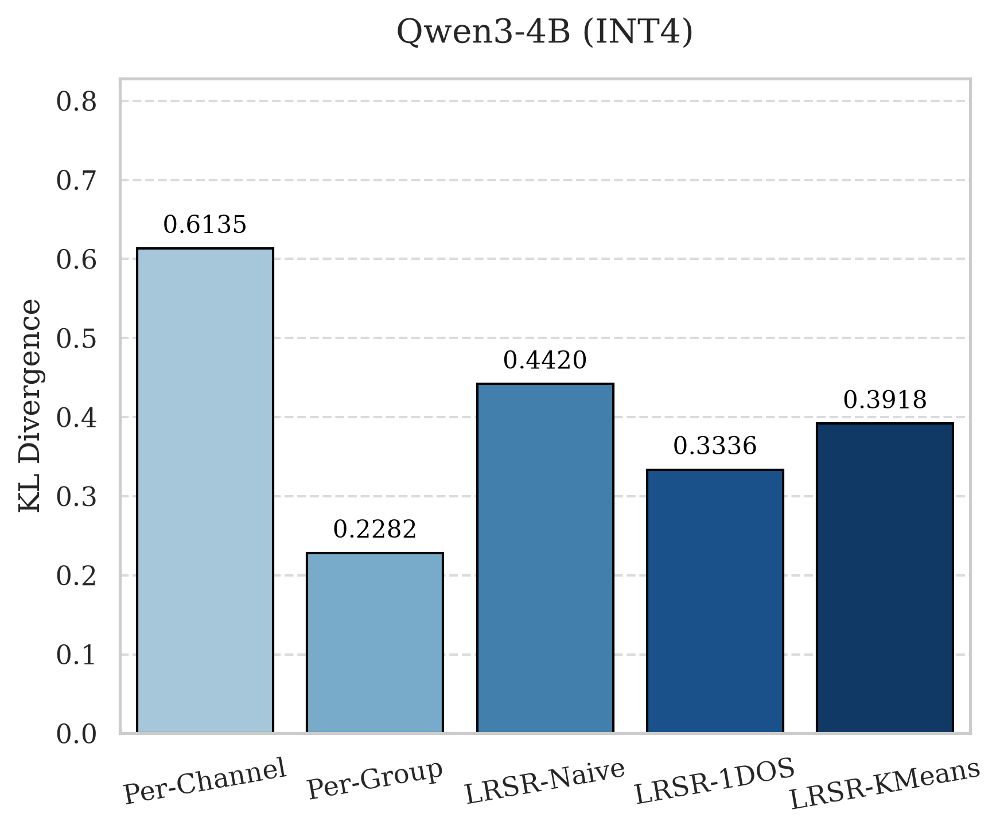

In [53]:
# Visualization
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

sns.barplot(
    data=df_filtered,
    x="method_display",
    y="mean_kld",
    hue="method_display",
    palette=PALETTE[:len(df_filtered)],
    edgecolor="black",
    linewidth=1.0,
    legend=False,
    ax=ax
)
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.set_title(title, fontsize=14, pad=15)
ax.set_ylabel("KL Divergence", fontsize=12)
ax.set_xlabel("")
ax.grid(axis="y", linestyle="--", alpha=0.7)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.4f}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center", va="bottom", fontsize=10, color="black",
            xytext=(0, 4), textcoords="offset points",
            rotation=0,
        )

ax.set_ylim(0, df_filtered["mean_kld"].max() * 1.35)
ax.tick_params(axis="x", rotation=10)

plt.tight_layout()
save_figure(fig, f"4d_logits_kl_divergence")
plt.show()

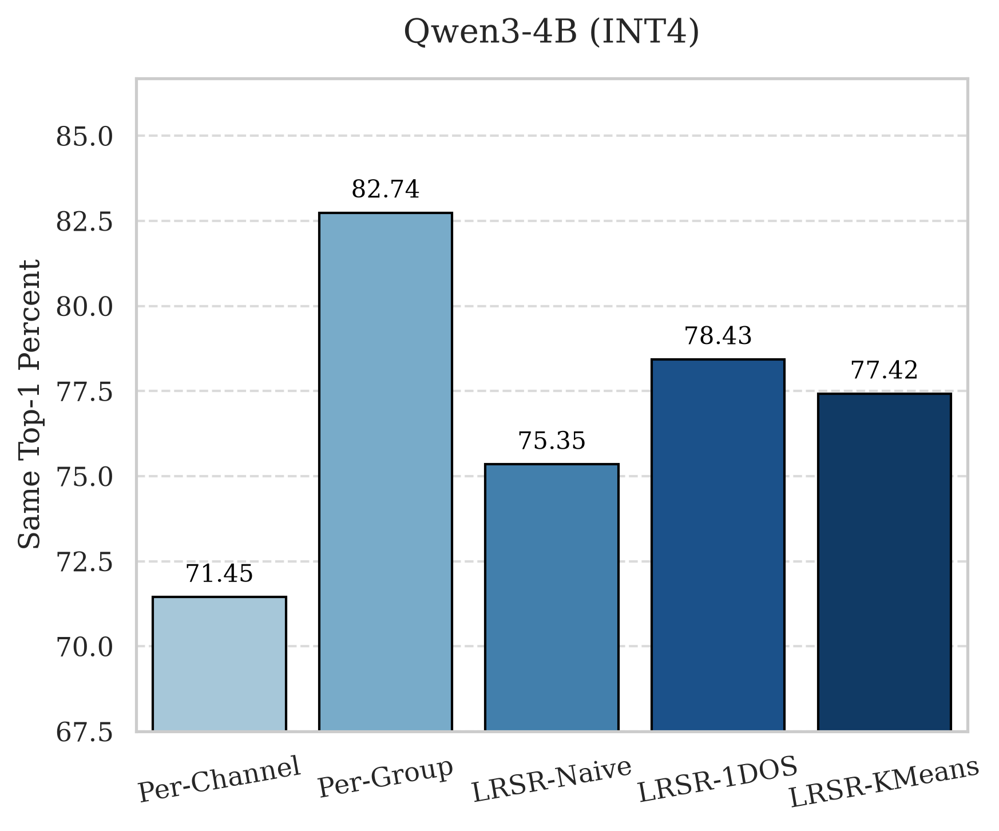

In [54]:
# Visualization
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

sns.barplot(
    data=df_filtered,
    x="method_display",
    y="same_top_1",
    hue="method_display",
    palette=PALETTE[:len(df_filtered)],
    edgecolor="black",
    linewidth=1.0,
    legend=False,
    ax=ax
)
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.set_title(title, fontsize=14, pad=15)
ax.set_ylabel("Same Top-1 Percent", fontsize=12)
ax.set_xlabel("")
ax.grid(axis="y", linestyle="--", alpha=0.7)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center", va="bottom", fontsize=10, color="black",
            xytext=(0, 4), textcoords="offset points",
        )

dynamic_ylim(ax, df_filtered["same_top_1"].values, margin=0.35)
ax.tick_params(axis="x", rotation=10)

plt.tight_layout()
save_figure(fig, f"4e_logits_top_1_percent")
plt.show()

In [55]:
RESULTS_FILE = Path("../benchmarks/runtime/result/results.json")
assert RESULTS_FILE.exists(), f"Runtime benchmark results file not found: {RESULTS_FILE.resolve()}"

In [56]:
# Configuration
METHOD_NAMES = {
    "per-channel": "Per-Channel",
    "per-group": "Per-Group",
    "lrsr-naive": "LRSR-Naive",
}

PHASE_TITLES = {
    "prefill": "Prefill",
    "decode": "Decode",
    "e2e": "End-to-End",
}

In [57]:
with open(RESULTS_FILE, "r") as f:
    runtime_data = json.load(f)

# Flatten JSON records
records = []
for record in runtime_data["records"]:
    records.append({
        "model": record["model"],
        "model_short": record["model"].split("/")[-1],
        "method": record["method"],
        "method_display": METHOD_NAMES.get(record["method"], record["method"]),
        "phase": record["phase"],
        "median_ms": record["time_ms"]["median"],
        "std_ms": record["time_ms"]["std"],
        "memory_b": record["memory_b"],
        "memory_mb": record["memory_b"] / (1024 ** 2),
    })

df_runtime = pd.DataFrame(records)

print(f"Loaded {len(df_runtime)} runtime benchmark records.")

Loaded 30 runtime benchmark records.


In [58]:
# Configuration
TARGET_MODEL = "Qwen/Qwen3-4B"
TARGET_METHODS = ["per-channel", "per-group", "lrsr-naive"]
PHASES = ["prefill", "decode", "e2e"]

In [59]:
# Filter configuration from the dataset
df_model = df_runtime[(df_runtime["model"] == TARGET_MODEL) & (df_runtime["method"].isin(TARGET_METHODS))].copy()
model_short = TARGET_MODEL.split("/")[-1]

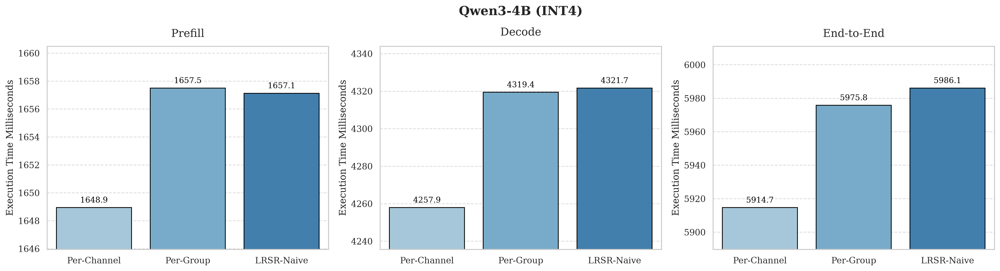

In [60]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for idx, phase in enumerate(PHASES):
    ax = axes[idx]
    df_phase = df_model[df_model["phase"] == phase].copy()
    df_phase["__order"] = df_phase["method"].map({m: i for i, m in enumerate(TARGET_METHODS)})
    df_phase = df_phase.sort_values("__order").reset_index(drop=True)

    sns.barplot(
        data=df_phase,
        x="method_display",
        y="median_ms",
        hue="method_display",
        palette=PALETTE[:len(TARGET_METHODS)],
        edgecolor="black",
        linewidth=1.0,
        legend=False,
        ax=ax
    )
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    if idx == len(PHASES) // 2:
        ax.set_title(title, fontsize=16, fontweight="bold", pad=40)
        ax.text(0.5, 1.04, PHASE_TITLES[phase], transform=ax.transAxes, ha="center", va="bottom", fontsize=14)
    else:
        ax.set_title(PHASE_TITLES[phase], fontsize=14, pad=12)

    ax.set_ylabel("Execution Time Milliseconds", fontsize=12)
    ax.set_xlabel("")
    ax.grid(axis="y", linestyle="--", alpha=0.7)

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f"{height:.1f}",
                (p.get_x() + p.get_width() / 2., height),
                ha="center", va="bottom", fontsize=10, color="black",
                xytext=(0, 4), textcoords="offset points",
            )

    dynamic_ylim(ax, df_phase["median_ms"].values, margin=0.35)

plt.tight_layout()
save_figure(fig, "4f_runtime_latency_by_phase")
plt.show()

In [61]:
# Calculate relative memory overhead
models_unique = df_runtime["model"].unique()
mem_rows = []

for model_name in models_unique:
    sub = df_runtime[df_runtime["model"] == model_name]

    mem_pc = sub[sub["method"] == "per-channel"]["memory_b"].iloc[0]
    mem_pg = sub[sub["method"] == "per-group"]["memory_b"].iloc[0]
    mem_lrsr = sub[sub["method"] == "lrsr-naive"]["memory_b"].iloc[0]

    delta_pg = mem_pg - mem_pc
    delta_lrsr = mem_lrsr - mem_pc

    overhead_pct = (delta_lrsr / delta_pg) * 100.0 if delta_pg > 0 else 0.0

    mem_rows.append({
        "model": model_name,
        "model_short": model_name.split("/")[-1],
        "mem_pc_mb": mem_pc / (1024 ** 2),
        "mem_pg_mb": mem_pg / (1024 ** 2),
        "mem_lrsr_mb": mem_lrsr / (1024 ** 2),
        "lrsr_delta_mb": delta_lrsr / (1024 ** 2),
        "pg_delta_mb": delta_pg / (1024 ** 2),
        "overhead_pct": overhead_pct,
    })

df_mem_overhead = pd.DataFrame(mem_rows)


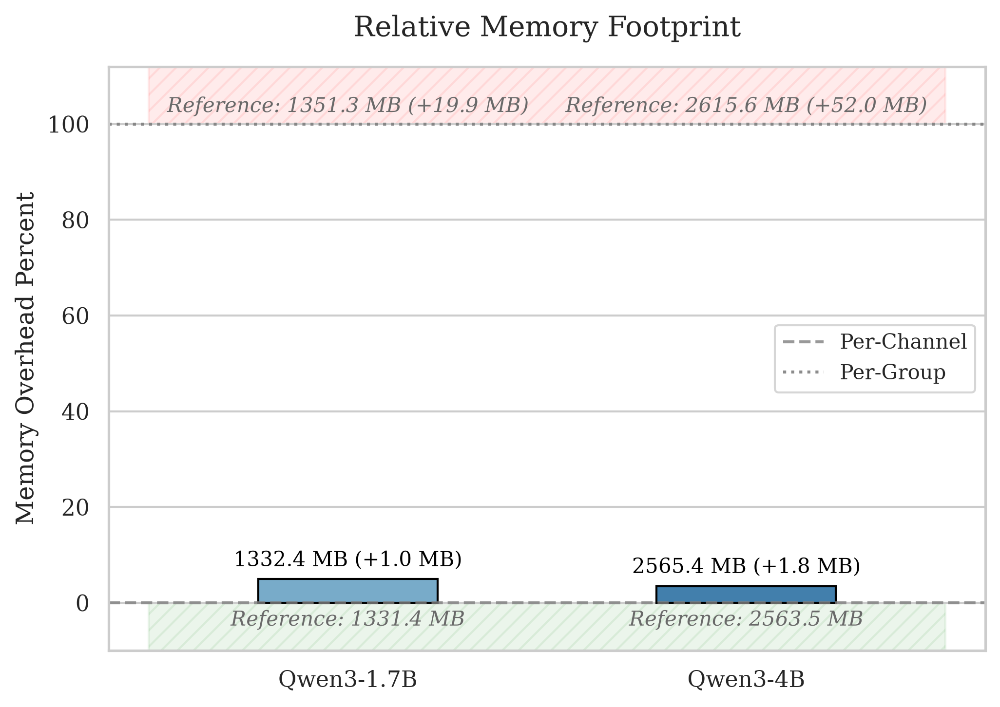

In [62]:
# Visualization
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

sns.barplot(
    data=df_mem_overhead,
    x="model_short",
    y="overhead_pct",
    hue="model_short",
    palette=PALETTE[1:1+len(df_mem_overhead)],
    edgecolor="black",
    linewidth=1.0,
    width=0.45,
    legend=False,
    ax=ax
)
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Baselines
line_pc = ax.axhline(0, color='gray', linestyle='--', alpha=0.8)
line_pg = ax.axhline(100, color='gray', linestyle=':', alpha=0.9)

ax.set_title("Relative Memory Footprint", fontsize=14, pad=15)
ax.set_xlabel("")
ax.set_ylabel("Memory Overhead Percent", fontsize=12)
ax.set_ylim(-10, 112)

shade_bounds(
    ax,
    x=[-0.5, len(df_mem_overhead) - 0.5],
    upper_y=100.0,
    lower_y=0.0,
    upper_color="red",
    lower_color="green",
)

# Annotate bars
for i, p in enumerate(ax.patches):
    height = p.get_height()
    row = df_mem_overhead.iloc[i]
    # Low-Rank Scale Reconstruction
    ax.annotate(
        f"{row['mem_lrsr_mb']:.1f} MB (+{row['lrsr_delta_mb']:.1f} MB)",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom", fontsize=10, color="black",
        xytext=(0, 4), textcoords="offset points",
    )
    # Per-Group reference
    ax.annotate(
        f"Reference: {row['mem_pg_mb']:.1f} MB (+{row['pg_delta_mb']:.1f} MB)",
        (p.get_x() + p.get_width() / 2., 101.5),
        ha="center", va="bottom", fontsize=10, color="dimgray", fontstyle="italic"
    )
    # Per-Channel reference
    ax.annotate(
        f"Reference: {row['mem_pc_mb']:.1f} MB",
        (p.get_x() + p.get_width() / 2., -1.5),
        ha="center", va="top", fontsize=10, color="dimgray", fontstyle="italic"
    )

ax.legend(
    [line_pc, line_pg],
    ["Per-Channel", "Per-Group"],
    loc="right",
    fontsize=10
)

plt.tight_layout()
save_figure(fig, "4g_runtime_memory_overhead")
plt.show()

### Visualizing the results of method expediency

In [63]:
# Configuration
TARGET_MODEL = "Qwen/Qwen3-4B"
BIT_WIDTH = 4
TARGET_METHODS = ["per-channel", "per-group", "lrsr-naive"]

In [64]:
# Extract accuracy metrics from logits benchmark
df_l = df_logits[
    (df_logits["model"] == TARGET_MODEL) &
    (df_logits["bits"] == BIT_WIDTH) &
    (df_logits["method"].isin(TARGET_METHODS))
].copy()

# Extract memory from runtime benchmark
df_r = df_runtime[
    (df_runtime["model"] == TARGET_MODEL) &
    (df_runtime["method"].isin(TARGET_METHODS)) &
    (df_runtime["phase"] == "prefill")
][["method", "memory_mb"]].copy()

# Combine benchmarks into a single tradeoff dataset
df_tradeoff = pd.merge(df_l, df_r, on="method")
df_tradeoff["method_display"] = df_tradeoff["method"].map(METHOD_NAMES)

# Sort strictly by methods order
df_tradeoff["__order"] = df_tradeoff["method"].map({m: i for i, m in enumerate(TARGET_METHODS)})
df_tradeoff = df_tradeoff.sort_values("__order").reset_index(drop=True)

model_short = TARGET_MODEL.split("/")[-1]

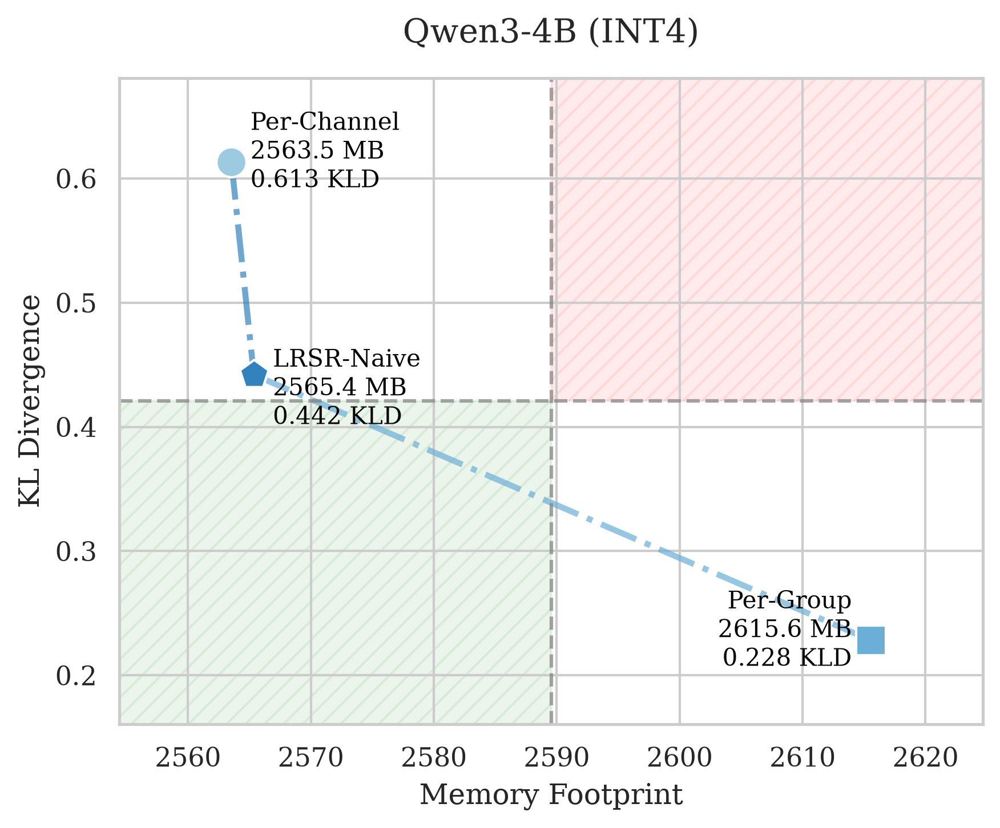

In [65]:
# Visualization
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# Center the window on the data span
x_center = (df_tradeoff["memory_mb"].min() + df_tradeoff["memory_mb"].max()) / 2.0
y_center = (df_tradeoff["mean_kld"].min() + df_tradeoff["mean_kld"].max()) / 2.0
x_half = (df_tradeoff["memory_mb"].max() - df_tradeoff["memory_mb"].min()) / 2.0 * 1.35
y_half = (df_tradeoff["mean_kld"].max() - df_tradeoff["mean_kld"].min()) / 2.0 * 1.35

x_min, x_max = x_center - x_half, x_center + x_half
y_min, y_max = y_center - y_half, y_center + y_half

# Best quadrant
ax.fill_between(
    [x_min, x_center], y_min, y_center,
    facecolor="green", alpha=0.08, hatch="///",
    edgecolor="green", linewidth=1.0, zorder=0
)

# Worst quadrant
ax.fill_between(
    [x_center, x_max], y_center, y_max,
    facecolor="red", alpha=0.08, hatch="///",
    edgecolor="red", linewidth=1.0, zorder=0
)

# Centered dividers
ax.axvline(x_center, color="gray", linestyle="--", alpha=0.7)
ax.axhline(y_center, color="gray", linestyle="--", alpha=0.7)

# Scatter points
for idx, row in df_tradeoff.iterrows():
    ax.scatter(
        row["memory_mb"],
        row["mean_kld"],
        color=PALETTE[idx],
        marker=MARKERS[idx],
        s=160,
        edgecolor="white",
        linewidth=1.0,
        zorder=3
    )

# Connect the methods
path = ["per-channel", "lrsr-naive", "per-group"]
df_path = df_tradeoff.set_index("method").loc[path]

for i in range(len(path) - 1):
    seg_from, seg_to = path[i], path[i + 1]
    ax.plot(
        [df_path.loc[seg_from, "memory_mb"], df_path.loc[seg_to, "memory_mb"]],
        [df_path.loc[seg_from, "mean_kld"], df_path.loc[seg_to, "mean_kld"]],
        color=PALETTE[TARGET_METHODS.index(seg_to)],
        linestyle='-.',
        linewidth=2.5,
        alpha=0.7,
        zorder=1
    )

# Annotate points
offsets = {
    "Per-Channel": (8, 4, "left"),
    "LRSR-Naive": (8, -6, "left"),
    "Per-Group": (-8, 4, "right"),
}

for _, row in df_tradeoff.iterrows():
    name = row["method_display"]
    dx, dy, ha = offsets.get(name, (6, 6, "left"))
    ax.annotate(
        f"{name}\n{row['memory_mb']:.1f} MB\n{row['mean_kld']:.3f} KLD",
        (row["memory_mb"], row["mean_kld"]),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha, va="center", fontsize=10, color="black",
    )

ax.set_title(title, fontsize=14, pad=15)
ax.set_xlabel("Memory Footprint", fontsize=12)
ax.set_ylabel("KL Divergence", fontsize=12)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
save_figure(fig, "5a_method_expediency_tradeoff")
plt.show()
